# Libraries

In [284]:
# === Сохранение и загрузка моделей ===
from joblib import dump, load  # Для сохранения и загрузки моделей
# === Работа с данными ===
import pandas as pd  # Для работы с таблицами (DataFrame)
import numpy as np  # Для работы с массивами и вычислений

# === Визуализация данных ===
import matplotlib.pyplot as plt  # Построение графиков
import seaborn as sns  # Расширенная визуализация данных
from matplotlib.colors import LinearSegmentedColormap  # Кастомные цветовые схемы

# === Астрономические данные ===
from astropy.io import fits  # Для работы с FITS-файлами (астрономические данные)
from astropy.table import Table

In [2]:
# Создаём кастомную цветовую карту
colors = [  "steelblue", "lightblue", "lightgreen", "green", "salmon", "orange"]
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)
# Превращаем градиент в список цветов
color_list = [custom_cmap(i/256) for i in range(256)]
plt.rcParams.update({
    'figure.figsize': (8, 6),  # Размеры графиков
    'figure.dpi': 100,  # Разрешение графиков
    'savefig.dpi': 300,  # Разрешение сохраненных изображений
    'font.size': 12,  # Размер шрифта
    'font.family': 'serif',  # Семейство шрифтов
    'axes.labelsize': 14,  # Размер шрифта для подписей осей
    'axes.titlesize': 14,  # Размер шрифта для заголовков
    'xtick.labelsize': 12,  # Размер шрифта для подписей меток на оси X
    'ytick.labelsize': 12,  # Размер шрифта для подписей меток на оси Y
    'legend.fontsize': 10,  # Размер шрифта для легенды
    'lines.linewidth': 1,  # Толщина линий
    'lines.markersize': 6,  # Размер маркеров
    'axes.grid': False,  # Сетка на графиках
    'grid.alpha': 0.25,  # Прозрачность сетки
    'grid.linestyle': '--',  # Стиль линии сетки
    'grid.color': 'lightgray',  # Цвет сетки
    'axes.axisbelow': True,  # Сетка ниже данных
    'image.cmap': 'viridis',  # Цветовая карта для изображений
    'errorbar.capsize': 3,  # Размер "колпачков" на графиках ошибок
    "legend.loc": 'best', 
})

# Catalogue

In [4]:
cat = pd.read_csv("updated_catalog_with_TESS.csv",low_memory=False)
cat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58202 entries, 0 to 58201
Data columns (total 81 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   NAME                    58202 non-null  object 
 1   RA                      58202 non-null  float64
 2   DEC                     58202 non-null  float64
 3   SPECT_TYPE              14935 non-null  object 
 4   MIN_MAG_LIMIT           9977 non-null   object 
 5   MIN_MAG                 58202 non-null  float64
 6   MAX_MAG_LIMIT           6 non-null      object 
 7   MAX_MAG                 58202 non-null  float64
 8   VARIABILITY_TYPE        57379 non-null  object 
 9   PERIOD_LIMIT            164 non-null    object 
 10  PERIOD                  58202 non-null  float64
 11  PERIOD_FLAG             2649 non-null   object 
 12  VARIABLE_STAR_NUMBER    58202 non-null  int64  
 13  VARIABLE_STAR_CPT       42 non-null     object 
 14  NOTE_FLAG               12718 non-null

In [5]:
cat_initial = cat.copy()

## General reduction

In [7]:
# Функция проверки: является ли значение числом или "--"
def is_numeric_or_dash(value):
    """Проверяет, можно ли преобразовать значение в число или является ли оно '--'."""
    try:
        float(value)  # Пробуем преобразовать в число
        return True
    except ValueError:
        return value == "--"  # Разрешаем также строку "--"

# Выбираем строки, удовлетворяющие условиям
mask = cat["phot_variable_flag"].apply(is_numeric_or_dash)

In [8]:
# Сдвиг значений в строках, соответствующих маске
for index in cat[mask].index:
    values = cat.loc[index, "SOURCE_ID":].values  # Извлекаем все значения с колонки SOURCE_ID
    last_three_values = values[-3:]  # Запоминаем последние три значения
    shifted_values = np.roll(values, shift=3)  # Сдвигаем весь массив на три позиции вправо
    shifted_values[:3] = last_three_values  # Переносим последние три значения в начало
    cat.loc[index, "SOURCE_ID":] = shifted_values  # Записываем обновленные данные

# Проверка уникальных значений
print(cat.phot_variable_flag.unique())

# Первичный анализ данных
print(cat.head())
print(cat.info())

/var/folders/kv/prhthx396zd4k1d7f55bdztc0000gn/T/ipykernel_20140/1301222224.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'RS:' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cat.loc[index, "SOURCE_ID":] = shifted_values  # Записываем обновленные данные
/var/folders/kv/prhthx396zd4k1d7f55bdztc0000gn/T/ipykernel_20140/1301222224.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value 'DA4.1' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  cat.loc[index, "SOURCE_ID":] = shifted_values  # Записываем обновленные данные
/var/folders/kv/prhthx396zd4k1d7f55bdztc0000gn/T/ipykernel_20140/1301222224.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '3.495090320714192e+18' has dtype incompatible wi

['VARIABLE' 'NOT_AVAILABLE' nan]
      NAME         RA       DEC         SPECT_TYPE MIN_MAG_LIMIT  MIN_MAG  \
0   EN Oct  222.56025 -89.78306                NaN           NaN    12.60   
1   BQ Oct  218.87283 -89.77172  M4III(S5,1)                   (     0.10   
2  sig Oct  317.19521 -88.95650               F0IV             (     0.05   
3   CG Oct  341.37592 -88.81831                NaN             (     0.04   
4    Y Oct  217.26825 -88.64547                NaN           NaN    12.80   

  MAX_MAG_LIMIT  MAX_MAG VARIABILITY_TYPE PERIOD_LIMIT  ...  TESS_Teff  \
0           NaN    11.88               EW          NaN  ...     5693.0   
1           NaN     6.80              LB:          NaN  ...     3464.0   
2           NaN     5.45            DSCTC          NaN  ...     7260.0   
3           NaN     6.85            DSCTC          NaN  ...     7446.0   
4           NaN    11.30             RRAB          NaN  ...     6571.0   

  TESS_logg  TESS_MH   TESS_rad TESS_mass  TESS_rho   TESS_

In [11]:
# === ОБЩАЯ ОЧИСТКА ДАННЫХ === #

# Заменяем пустые значения и "--" на NaN
print("Замена пустых значений и '--' на NaN")
cat.replace("--", np.NaN, inplace=True)
cat.replace(r'^\s*$', np.NaN, regex=True, inplace=True)

# Фильтруем строки с нулевыми координатами RA и DEC
cat = cat[(cat["RA"] != 0) & (cat["DEC"] != 0)].reset_index(drop=True)
print(cat.info())

Замена пустых значений и '--' на NaN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58023 entries, 0 to 58022
Data columns (total 81 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   NAME                    58023 non-null  object 
 1   RA                      58023 non-null  float64
 2   DEC                     58023 non-null  float64
 3   SPECT_TYPE              14935 non-null  object 
 4   MIN_MAG_LIMIT           9977 non-null   object 
 5   MIN_MAG                 58023 non-null  float64
 6   MAX_MAG_LIMIT           6 non-null      object 
 7   MAX_MAG                 58023 non-null  float64
 8   VARIABILITY_TYPE        57365 non-null  object 
 9   PERIOD_LIMIT            164 non-null    object 
 10  PERIOD                  58023 non-null  float64
 11  PERIOD_FLAG             2647 non-null   object 
 12  VARIABLE_STAR_NUMBER    58023 non-null  int64  
 13  VARIABLE_STAR_CPT       42 non-null     object 
 14  N

In [12]:
# === ОБРАБОТКА ПЕРИОДА === #

# Добавляем бинарные столбцы, указывающие тип периодичности
print("Обработка PERIOD_LIMIT")
cat['is_bound_period_final'] = cat['PERIOD_LIMIT'].apply(lambda x: 1 if x in ['>', '<'] else 0)
cat['is_mean_cycle_period_final'] = cat['PERIOD_LIMIT'].apply(lambda x: 1 if x == '(' else 0)
cat.drop("PERIOD_LIMIT", axis=1, inplace=True)

# Удаляем строки с неинформативными значениями PERIOD_FLAG
cat = cat[~cat['PERIOD_FLAG'].isin(['/', '(', ':'])].reset_index(drop=True)
cat.drop("PERIOD_FLAG", axis=1, inplace=True)
print(cat.info())

Обработка PERIOD_LIMIT
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55376 entries, 0 to 55375
Data columns (total 81 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   NAME                        55376 non-null  object 
 1   RA                          55376 non-null  float64
 2   DEC                         55376 non-null  float64
 3   SPECT_TYPE                  14091 non-null  object 
 4   MIN_MAG_LIMIT               9373 non-null   object 
 5   MIN_MAG                     55376 non-null  float64
 6   MAX_MAG_LIMIT               6 non-null      object 
 7   MAX_MAG                     55376 non-null  float64
 8   VARIABILITY_TYPE            54720 non-null  object 
 9   PERIOD                      55376 non-null  float64
 10  VARIABLE_STAR_NUMBER        55376 non-null  int64  
 11  VARIABLE_STAR_CPT           36 non-null     object 
 12  NOTE_FLAG                   12199 non-null  object 
 13  LII     

In [13]:
# === ОБРАБОТКА СОБСТВЕННОГО ДВИЖЕНИЯ (pm) === #

print("Обнуление значений pm -> NaN")
for col in ["pmra", "pmdec", "pm"]:
    cat[col] = cat[col].replace(0, np.NaN).astype("float")
print(cat[["pm", "pmra", "pmdec"]].info())

Обнуление значений pm -> NaN
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55376 entries, 0 to 55375
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   pm      50605 non-null  float64
 1   pmra    50605 non-null  float64
 2   pmdec   50605 non-null  float64
dtypes: float64(3)
memory usage: 1.3 MB
None


In [14]:
# === ОБРАБОТКА ФОТОМЕТРИЧЕСКИХ ПАРАМЕТРОВ === #

cat["phot_g_mean_mag"] = cat["phot_g_mean_mag"].replace(0, np.NaN).astype("float")
cat[["bp_rp", "bp_g", "g_rp"]] = cat[["bp_rp", "bp_g", "g_rp"]].replace(0, np.NaN).astype("float")
print(cat[["bp_rp", "bp_g", "g_rp"]].describe())

              bp_rp          bp_g          g_rp
count  49569.000000  49574.000000  49609.000000
mean       2.093751      1.131658      0.962870
std        1.749549      1.336064      0.610838
min       -2.025822     -6.631654     -0.818087
25%        0.731171      0.244138      0.470147
50%        1.340877      0.513682      0.841497
75%        3.189580      1.824959      1.384095
max        8.752645      6.660159      7.562619


In [15]:
# === ОБРАБОТКА ФОРМАТА ДАННЫХ === #

# Преобразуем числовые столбцы, содержащие строки
obj_columns = ["LII", "BII", "parallax", "bp_rp", "bp_g", "g_rp", "TESS_Teff", "logg_gspphot", "mh_gspphot", "ag_gspphot", "ebpminrp_gspphot"]
for col in obj_columns:
    cat[col] = cat[col].astype(str).str.replace(r'[^0-9\.-]', '', regex=True)
    cat[col] = pd.to_numeric(cat[col], errors='coerce')
print(cat.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55376 entries, 0 to 55375
Data columns (total 81 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   NAME                        55376 non-null  object 
 1   RA                          55376 non-null  float64
 2   DEC                         55376 non-null  float64
 3   SPECT_TYPE                  14091 non-null  object 
 4   MIN_MAG_LIMIT               9373 non-null   object 
 5   MIN_MAG                     55376 non-null  float64
 6   MAX_MAG_LIMIT               6 non-null      object 
 7   MAX_MAG                     55376 non-null  float64
 8   VARIABILITY_TYPE            54720 non-null  object 
 9   PERIOD                      55376 non-null  float64
 10  VARIABLE_STAR_NUMBER        55376 non-null  int64  
 11  VARIABLE_STAR_CPT           36 non-null     object 
 12  NOTE_FLAG                   12199 non-null  object 
 13  LII                         553

In [19]:
# === ВЫЧИСЛЕНИЕ ГАЛАКТИЧЕСКОГО РАССТОЯНИЯ === #

R_sun = 8.2  # В кпк
cat['R_gal'] = np.sqrt(
    R_sun**2 + (1 / cat['parallax'])**2 -
    2 * R_sun * (1 / cat['parallax']) * np.cos(np.radians(cat['LII'])) * np.cos(np.radians(cat['BII']))
)

In [20]:
# === ЛОГАРИФМИРОВАНИЕ ДАННЫХ === #

def log_transform_if_needed(df, cols, threshold=2):
    """Логарифмирует числовые признаки с большим разбросом значений."""
    columns_to_log = ['PERIOD', 'parallax', 'TESS_Teff', 'TESS_rad', 'TESS_lum', 'TESS_rho', 'ag_gspphot', 'TESS_d', 'TESS_ebv', 'R_gal']
    log_transformed_cols = []
    
    for col in cols:
        if col in columns_to_log:
            valid_values = df[col].dropna()
            valid_values = valid_values[valid_values > 0]
            
            if len(valid_values) > 0 and valid_values.max() / valid_values.min() >= 10 ** threshold:
                df[col + '_log'] = np.log10(valid_values + 1e-6)
                log_transformed_cols.append(col)
    
    return df, log_transformed_cols

# Применение логарифмирования
cat_log, transformed_columns = log_transform_if_needed(cat, cat.select_dtypes(include=[np.number]).columns.tolist())
print("Логарифмированные столбцы:", transformed_columns)

cat_log.head()

Логарифмированные столбцы: ['PERIOD', 'parallax', 'ag_gspphot', 'TESS_Teff', 'TESS_rad', 'TESS_rho', 'TESS_lum', 'TESS_d', 'TESS_ebv', 'R_gal']


,NAME,RA,DEC,SPECT_TYPE,MIN_MAG_LIMIT,MIN_MAG,MAX_MAG_LIMIT,MAX_MAG,VARIABILITY_TYPE,PERIOD,...,PERIOD_log,parallax_log,ag_gspphot_log,TESS_Teff_log,TESS_rad_log,TESS_rho_log,TESS_lum_log,TESS_d_log,TESS_ebv_log,R_gal_log
0,EN Oct,222.56025,-89.78306,NaN,NaN,12.60,NaN,11.88,EW,0.288906,...,-0.539242,0.578553,-2.200591,3.755341,0.019075,-0.052903,0.014210,2.426386,-1.104366,0.907141
1,BQ Oct,218.87283,-89.77172,"M4III(S5,1)",(,0.10,NaN,6.80,LB:,0.000000,...,NaN,0.260960,NaN,3.539578,2.293597,NaN,NaN,2.764863,-0.963080,0.900251
2,sig Oct,317.19521,-88.95650,F0IV,(,0.05,NaN,5.45,DSCTC,0.097000,...,-1.013224,1.045342,-1.322384,3.860937,0.611174,-1.621317,1.620789,1.954001,NaN,0.911471
3,CG Oct,341.37592,-88.81831,NaN,(,0.04,NaN,6.85,DSCTC,0.000000,...,NaN,0.984138,-2.070530,3.871923,0.452466,-1.124393,1.347317,2.014344,-1.399162,0.911149
4,Y Oct,217.26825,-88.64547,NaN,NaN,12.80,NaN,11.30,RRAB,0.646626,...,-0.189346,-0.310398,NaN,3.817631,0.787694,NaN,NaN,3.352256,-0.932223,0.869198


## Variability

In [22]:
cat_var = cat[cat.VARIABILITY_TYPE.isna()]
cat_var.info()

<class 'pandas.core.frame.DataFrame'>
Index: 656 entries, 5 to 55054
Data columns (total 92 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   NAME                        656 non-null    object 
 1   RA                          656 non-null    float64
 2   DEC                         656 non-null    float64
 3   SPECT_TYPE                  205 non-null    object 
 4   MIN_MAG_LIMIT               304 non-null    object 
 5   MIN_MAG                     656 non-null    float64
 6   MAX_MAG_LIMIT               0 non-null      object 
 7   MAX_MAG                     656 non-null    float64
 8   VARIABILITY_TYPE            0 non-null      object 
 9   PERIOD                      656 non-null    float64
 10  VARIABLE_STAR_NUMBER        656 non-null    int64  
 11  VARIABLE_STAR_CPT           0 non-null      object 
 12  NOTE_FLAG                   53 non-null     object 
 13  LII                         656 non-nu

In [23]:
# Удаление строк с NaN для нужных столбцов
columns_to_check_var = [    "LII", "BII", "parallax_log", "pmra", "pmdec", "pm",
    "phot_g_mean_mag", "bp_rp", "bp_g", "g_rp", "is_bound_period_final",
    "is_mean_cycle_period_final", "PERIOD_log", "TESS_Teff_log",
    "logg_gspphot", "mh_gspphot", "ag_gspphot_log", "ebpminrp_gspphot",
    "TESS_rad_log", "TESS_mass", "TESS_rho_log", "TESS_lum_log",
    "TESS_d_log", "TESS_ebv_log", "TESS_Tmag", "R_gal_log"]
cat_var_cut = cat_var[columns_to_check_var]#.dropna(subset=columns_to_check)

In [24]:
cat_var_cut.info()

<class 'pandas.core.frame.DataFrame'>
Index: 656 entries, 5 to 55054
Data columns (total 26 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LII                         656 non-null    float64
 1   BII                         656 non-null    float64
 2   parallax_log                475 non-null    float64
 3   pmra                        557 non-null    float64
 4   pmdec                       557 non-null    float64
 5   pm                          557 non-null    float64
 6   phot_g_mean_mag             618 non-null    float64
 7   bp_rp                       547 non-null    float64
 8   bp_g                        547 non-null    float64
 9   g_rp                        548 non-null    float64
 10  is_bound_period_final       656 non-null    int64  
 11  is_mean_cycle_period_final  656 non-null    int64  
 12  PERIOD_log                  7 non-null      float64
 13  TESS_Teff_log               275 non-nu

In [25]:
model_var = load('output/ml_joblib/model_var_xgboost_full.joblib')
X_var = cat_var_cut
X_filtered_var = X_var[model_var.get_booster().feature_names]

/opt/anaconda3/lib/python3.11/site-packages/xgboost/core.py:158: UserWarning: [13:22:31] WARNING: /Users/runner/work/xgboost/xgboost/src/gbm/../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)


In [26]:
X_filtered_var.info()

<class 'pandas.core.frame.DataFrame'>
Index: 656 entries, 5 to 55054
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   LII                         656 non-null    float64
 1   BII                         656 non-null    float64
 2   parallax_log                475 non-null    float64
 3   pm                          557 non-null    float64
 4   phot_g_mean_mag             618 non-null    float64
 5   bp_rp                       547 non-null    float64
 6   bp_g                        547 non-null    float64
 7   g_rp                        548 non-null    float64
 8   is_mean_cycle_period_final  656 non-null    int64  
 9   PERIOD_log                  7 non-null      float64
 10  TESS_Teff_log               275 non-null    float64
 11  logg_gspphot                224 non-null    float64
 12  mh_gspphot                  224 non-null    float64
 13  ag_gspphot_log              224 non-nu

In [27]:
predictions_var = model_var.predict(X_filtered_var)

In [28]:
predictions_var

array([[0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       ...,
       [0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0.]])

In [29]:
# Загружаем сохранённый MultiLabelBinarizer
mlb_var = load('output/ml_joblib/mlb_binarizer_xgb_var.joblib')
print("MultiLabelBinarizer loaded successfully.")

# Расшифровываем предсказания
decoded_predictions_var = mlb_var.inverse_transform(predictions_var)

# Выводим расшифрованные предсказания
print(decoded_predictions_var)

MultiLabelBinarizer loaded successfully.
[('Pulsating',), (), ('Pulsating',), (), ('Cataclysmic',), (), ('Pulsating',), ('Pulsating',), (), (), ('Cataclysmic',), ('Pulsating',), ('Pulsating',), (), ('Cataclysmic',), ('Pulsating',), ('Pulsating',), ('Pulsating',), ('Pulsating',), ('Pulsating',), ('Pulsating',), ('Cataclysmic',), (), ('Pulsating',), ('Cataclysmic',), ('Cataclysmic',), ('Cataclysmic',), ('Cataclysmic',), ('Cataclysmic',), ('Cataclysmic',), ('Pulsating',), ('Cataclysmic',), ('Pulsating',), (), ('Cataclysmic',), (), ('Cataclysmic',), ('Pulsating',), ('Pulsating',), ('Eclipsing',), ('Cataclysmic',), ('Pulsating',), ('Cataclysmic',), ('Pulsating',), ('Pulsating',), ('Pulsating',), ('Cataclysmic',), ('Pulsating',), (), ('Pulsating',), ('Cataclysmic',), (), ('Cataclysmic',), ('Cataclysmic',), ('Cataclysmic',), ('Cataclysmic',), (), ('Eclipsing',), (), (), ('Eclipsing',), ('Cataclysmic',), ('Cataclysmic',), ('Cataclysmic', 'Eclipsing'), (), (), ('Pulsating',), ('Pulsating',), ('

/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator MultiLabelBinarizer from version 1.6.1 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [30]:
# Преобразуем в читаемый формат
decoded_predictions_var = ['+'.join(pred) for pred in mlb_var.inverse_transform(predictions_var)]

# Пример вывода
for obj_id, prediction in enumerate(decoded_predictions_var):
    print(f"Object {obj_id}: {prediction}")

Object 0: Pulsating
Object 1: 
Object 2: Pulsating
Object 3: 
Object 4: Cataclysmic
Object 5: 
Object 6: Pulsating
Object 7: Pulsating
Object 8: 
Object 9: 
Object 10: Cataclysmic
Object 11: Pulsating
Object 12: Pulsating
Object 13: 
Object 14: Cataclysmic
Object 15: Pulsating
Object 16: Pulsating
Object 17: Pulsating
Object 18: Pulsating
Object 19: Pulsating
Object 20: Pulsating
Object 21: Cataclysmic
Object 22: 
Object 23: Pulsating
Object 24: Cataclysmic
Object 25: Cataclysmic
Object 26: Cataclysmic
Object 27: Cataclysmic
Object 28: Cataclysmic
Object 29: Cataclysmic
Object 30: Pulsating
Object 31: Cataclysmic
Object 32: Pulsating
Object 33: 
Object 34: Cataclysmic
Object 35: 
Object 36: Cataclysmic
Object 37: Pulsating
Object 38: Pulsating
Object 39: Eclipsing
Object 40: Cataclysmic
Object 41: Pulsating
Object 42: Cataclysmic
Object 43: Pulsating
Object 44: Pulsating
Object 45: Pulsating
Object 46: Cataclysmic
Object 47: Pulsating
Object 48: 
Object 49: Pulsating
Object 50: Catacly

In [31]:
df_predictions_var = X_filtered_var.copy()  # Копируем таблицу
df_predictions_var["predicted_class_var"] = decoded_predictions_var  # Добавляем колонку с предсказаниями

In [32]:
df_predictions_var

,LII,BII,parallax_log,pm,phot_g_mean_mag,bp_rp,bp_g,g_rp,is_mean_cycle_period_final,PERIOD_log,...,ebpminrp_gspphot,TESS_rad_log,TESS_mass,TESS_rho_log,TESS_lum_log,TESS_d_log,TESS_ebv_log,TESS_Tmag,R_gal_log,predicted_class_var
5,304.56003,-26.97679,-0.569685,7.403766,13.565414,0.794462,0.303467,0.490995,0,NaN,...,0.2185,0.803435,NaN,NaN,NaN,3.612249,-0.790863,13.1456,0.850535,Pulsating
253,295.57424,-21.04383,0.778461,37.146633,5.059154,-0.173686,-0.068672,-0.105014,0,NaN,...,0.0049,NaN,NaN,NaN,NaN,2.245772,-1.304356,5.2505,0.910322,
294,300.11310,-36.64796,0.288554,14.058155,6.624005,4.449480,2.943429,1.506051,0,NaN,...,NaN,NaN,NaN,NaN,NaN,2.665437,-1.136092,5.0575,0.903456,Pulsating
982,320.51782,-32.10539,-0.256000,9.535398,14.227842,1.170324,0.507316,0.663009,0,NaN,...,NaN,0.495002,NaN,NaN,NaN,3.228485,-1.220803,13.6337,0.854460,
1074,304.66690,-43.79842,NaN,NaN,21.107021,0.241198,-0.257111,0.498308,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.7520,NaN,Cataclysmic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53080,97.31369,9.81897,-0.423845,2.949998,19.276915,-0.317545,-1.183203,0.865658,0,NaN,...,NaN,NaN,NaN,NaN,NaN,3.336762,0.021177,18.9240,0.950841,Cataclysmic
53184,95.87958,12.29615,-0.239173,5.867390,15.900781,1.214078,0.194762,1.019316,0,0.869232,...,NaN,1.021611,NaN,NaN,NaN,3.253890,-0.549028,11.7460,0.931946,Eclipsing
53197,95.90491,12.31947,-0.271365,5.751307,13.508595,1.162933,0.496139,0.666795,0,0.113944,...,0.6711,0.643689,NaN,NaN,NaN,3.265617,-0.582663,12.9189,0.934053,Eclipsing
53238,110.64728,0.39858,NaN,2.378067,19.981487,1.524319,0.586100,0.938219,0,NaN,...,NaN,NaN,NaN,NaN,NaN,3.453942,-0.041133,19.1510,0.885070,Cataclysmic


In [33]:
df_predictions_var#[df_predictions_var["predicted_class_var"]=='']

,LII,BII,parallax_log,pm,phot_g_mean_mag,bp_rp,bp_g,g_rp,is_mean_cycle_period_final,PERIOD_log,...,ebpminrp_gspphot,TESS_rad_log,TESS_mass,TESS_rho_log,TESS_lum_log,TESS_d_log,TESS_ebv_log,TESS_Tmag,R_gal_log,predicted_class_var
5,304.56003,-26.97679,-0.569685,7.403766,13.565414,0.794462,0.303467,0.490995,0,NaN,...,0.2185,0.803435,NaN,NaN,NaN,3.612249,-0.790863,13.1456,0.850535,Pulsating
253,295.57424,-21.04383,0.778461,37.146633,5.059154,-0.173686,-0.068672,-0.105014,0,NaN,...,0.0049,NaN,NaN,NaN,NaN,2.245772,-1.304356,5.2505,0.910322,
294,300.11310,-36.64796,0.288554,14.058155,6.624005,4.449480,2.943429,1.506051,0,NaN,...,NaN,NaN,NaN,NaN,NaN,2.665437,-1.136092,5.0575,0.903456,Pulsating
982,320.51782,-32.10539,-0.256000,9.535398,14.227842,1.170324,0.507316,0.663009,0,NaN,...,NaN,0.495002,NaN,NaN,NaN,3.228485,-1.220803,13.6337,0.854460,
1074,304.66690,-43.79842,NaN,NaN,21.107021,0.241198,-0.257111,0.498308,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.7520,NaN,Cataclysmic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53080,97.31369,9.81897,-0.423845,2.949998,19.276915,-0.317545,-1.183203,0.865658,0,NaN,...,NaN,NaN,NaN,NaN,NaN,3.336762,0.021177,18.9240,0.950841,Cataclysmic
53184,95.87958,12.29615,-0.239173,5.867390,15.900781,1.214078,0.194762,1.019316,0,0.869232,...,NaN,1.021611,NaN,NaN,NaN,3.253890,-0.549028,11.7460,0.931946,Eclipsing
53197,95.90491,12.31947,-0.271365,5.751307,13.508595,1.162933,0.496139,0.666795,0,0.113944,...,0.6711,0.643689,NaN,NaN,NaN,3.265617,-0.582663,12.9189,0.934053,Eclipsing
53238,110.64728,0.39858,NaN,2.378067,19.981487,1.524319,0.586100,0.938219,0,NaN,...,NaN,NaN,NaN,NaN,NaN,3.453942,-0.041133,19.1510,0.885070,Cataclysmic


In [306]:
df_predictions_var[df_predictions_var["predicted_class_var"]=='']

,LII,BII,parallax_log,pm,phot_g_mean_mag,bp_rp,bp_g,g_rp,is_mean_cycle_period_final,PERIOD_log,...,ebpminrp_gspphot,TESS_rad_log,TESS_mass,TESS_rho_log,TESS_lum_log,TESS_d_log,TESS_ebv_log,TESS_Tmag,R_gal_log,predicted_class_var
253,295.57424,-21.04383,0.778461,37.146633,5.059154,-0.173686,-0.068672,-0.105014,0,NaN,...,0.0049,NaN,NaN,NaN,NaN,2.245772,-1.304356,5.250500,0.910322,
982,320.51782,-32.10539,-0.256000,9.535398,14.227842,1.170324,0.507316,0.663009,0,NaN,...,NaN,0.495002,NaN,NaN,NaN,3.228485,-1.220803,13.633700,0.854460,
1221,301.91247,-44.74487,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,...,NaN,4.071698,4.41965,NaN,0.256982,0.495544,-0.275400,56.944237,NaN,
1718,283.62022,-40.14441,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
1955,310.93262,-6.44343,-0.462971,6.460496,10.956136,2.165784,1.118620,1.047164,0,NaN,...,0.9876,NaN,NaN,NaN,NaN,3.470887,-0.417462,9.898800,0.824999,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48401,87.79761,-1.78125,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,
50714,105.95655,-7.06060,-0.032170,9.809936,17.387472,1.843224,0.911652,0.931572,0,NaN,...,0.4549,-0.036305,0.64000,-0.084903,-0.683810,3.039005,-0.942303,16.525900,0.932309,
50914,103.10758,-4.85505,-0.237826,2.965915,14.463410,0.478279,0.161289,0.316990,0,NaN,...,NaN,0.054223,1.94000,0.125130,0.679189,3.195750,-0.767934,14.243000,0.942221,
51163,99.61371,-1.63814,-0.128559,5.976041,19.940296,NaN,NaN,NaN,0,NaN,...,NaN,3.864926,3.77074,NaN,0.443718,0.220108,-1.111041,20.037150,0.930853,


In [308]:
df_predictions_var["predicted_class_var"].value_counts()

predicted_class_var
Pulsating                336
Cataclysmic              162
                         105
Eclipsing                 33
Eruptive                   9
Cataclysmic+Pulsating      5
Eclipsing+Pulsating        2
Rotating                   2
Cataclysmic+Eclipsing      1
Cataclysmic+Eruptive       1
Name: count, dtype: int64

In [314]:
# Подсчитаем количество объектов, у которых изначально не было информации о типе переменности
num_missing_var = 656
# Подсчитаем, сколько из них получили предсказанный класс (не пустой)
num_predicted_var = (df_predictions_var["predicted_class_var"] != "").sum()

# Выведем статистику
num_missing_var, num_predicted_var, (num_predicted_var / num_missing_var) * 100

(656, 551, 83.9939024390244)

# Spec

In [35]:
cat_spec = cat[cat.SPECT_TYPE.isna()]

In [36]:
cat_spec

,NAME,RA,DEC,SPECT_TYPE,MIN_MAG_LIMIT,MIN_MAG,MAX_MAG_LIMIT,MAX_MAG,VARIABILITY_TYPE,PERIOD,...,PERIOD_log,parallax_log,ag_gspphot_log,TESS_Teff_log,TESS_rad_log,TESS_rho_log,TESS_lum_log,TESS_d_log,TESS_ebv_log,R_gal_log
0,EN Oct,222.56025,-89.78306,NaN,NaN,12.60,NaN,11.88,EW,0.288906,...,-0.539242,0.578553,-2.200591,3.755341,0.019075,-0.052903,0.014210,2.426386,-1.104366,0.907141
3,CG Oct,341.37592,-88.81831,NaN,(,0.04,NaN,6.85,DSCTC,0.000000,...,NaN,0.984138,-2.070530,3.871923,0.452466,-1.124393,1.347317,2.014344,-1.399162,0.911149
4,Y Oct,217.26825,-88.64547,NaN,NaN,12.80,NaN,11.30,RRAB,0.646626,...,-0.189346,-0.310398,NaN,3.817631,0.787694,NaN,NaN,3.352256,-0.932223,0.869198
5,RW Oct,277.26700,-88.54214,NaN,NaN,13.60,NaN,12.80,NaN,0.000000,...,NaN,-0.569685,-0.394586,3.819939,0.803435,NaN,NaN,3.612249,-0.790863,0.850535
6,W Oct,142.24029,-88.49353,NaN,NaN,13.00,NaN,11.50,CST:,0.000000,...,NaN,-0.516439,-0.861378,3.828853,0.759784,NaN,NaN,3.490948,-1.015518,0.860786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55367,UY UMi,183.83450,87.70011,NaN,NaN,6.38,NaN,6.30,GDOR:,0.000000,...,NaN,1.324626,NaN,3.840106,0.223556,-0.491690,0.762231,1.684974,NaN,0.915019
55369,AI UMi,294.22350,88.45644,NaN,NaN,14.70,NaN,14.00,EW,0.313848,...,-0.503279,0.229670,-1.131350,3.714833,0.096754,-0.345776,0.007532,2.774171,-1.089240,0.928847
55370,ST UMi,286.86371,88.77044,NaN,NaN,15.80,NaN,14.00,RRAB,0.000000,...,NaN,-0.825027,-0.303468,3.807806,0.651674,-1.841050,1.489266,3.678260,-0.769487,1.106107
55371,SU UMi,331.36504,88.84686,NaN,>,17.40,NaN,16.00,EA/SD:,0.000000,...,NaN,-0.624481,-0.036164,3.794767,0.507338,-1.439215,1.148437,3.578908,-0.739743,1.035720


In [37]:
# Удаление строк с NaN для нужных столбцов
columns_to_check_spec = ["LII", "BII", "parallax_log", "pmra", "pmdec", "pm",
    "phot_g_mean_mag", "bp_rp", "bp_g", "g_rp", "is_bound_period_final",
    "is_mean_cycle_period_final", "PERIOD_log", "TESS_Teff_log",
    "logg_gspphot", "mh_gspphot", "ag_gspphot_log", "ebpminrp_gspphot",
    "TESS_rad_log", "TESS_mass", "TESS_rho_log", "TESS_lum_log",
    "TESS_d_log", "TESS_ebv_log", "TESS_Tmag", "R_gal_log"]

cat_spec_cut = cat_spec[columns_to_check_spec]#.dropna(subset=columns_to_check)

In [38]:
model_spec = load('output/ml_joblib/model_spec_xgboost_full.joblib')
X_spec = cat_spec_cut
X_filtered_spec = X_spec[model_spec.get_booster().feature_names]

In [39]:
predictions_spec = model_spec.predict(X_filtered_spec)
predictions_spec

array([4, 0, 0, ..., 0, 3, 6])

In [40]:
# Загружаем сохранённый MultiLabelBinarizer
ohe_spec = load('output/ml_joblib/onehot_encoder_spectral.joblib')

# Преобразуем индексы предсказанных классов в one-hot формат
predictions_onehot = np.zeros((len(predictions_spec), len(ohe_spec.categories_[0])))
predictions_onehot[np.arange(len(predictions_spec)), predictions_spec] = 1

# Выполняем обратное преобразование
decoded_predictions_spec = ohe_spec.inverse_transform(predictions_onehot)
print(decoded_predictions_spec)

[['G']
 ['A']
 ['A']
 ...
 ['A']
 ['F']
 ['M']]


/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:318: UserWarning: Trying to unpickle estimator OneHotEncoder from version 1.6.1 when using version 1.2.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [41]:
decoded_predictions_spec

array([['G'],
       ['A'],
       ['A'],
       ...,
       ['A'],
       ['F'],
       ['M']], dtype=object)

In [42]:
df_predictions_spec = X_filtered_spec.copy()  # Копируем таблицу
df_predictions_spec["predicted_class_spec"] = decoded_predictions_spec.ravel()  # Добавляем колонку с предсказаниями

In [43]:
df_predictions_spec

,LII,BII,parallax_log,pmra,pmdec,pm,phot_g_mean_mag,bp_rp,bp_g,g_rp,...,ebpminrp_gspphot,TESS_rad_log,TESS_mass,TESS_rho_log,TESS_lum_log,TESS_d_log,TESS_ebv_log,TESS_Tmag,R_gal_log,predicted_class_spec
0,303.05249,-26.93976,0.578553,-5.210282,4.755414,7.054148,11.980466,0.945226,0.369872,0.575354,...,0.0034,0.019075,1.01,-0.052903,0.014210,2.426386,-1.104366,11.50090,0.907141,G
3,303.63172,-28.13425,0.984138,22.188353,-35.803178,42.121143,6.500398,0.402781,0.139544,0.263236,...,0.0046,0.452466,1.71,-1.124393,1.347317,2.014344,-1.399162,6.27790,0.911149,A
4,303.55409,-25.89342,-0.310398,-25.733357,1.252075,25.763800,12.249489,0.717911,0.218515,0.499395,...,NaN,0.787694,NaN,NaN,NaN,3.352256,-0.932223,11.84950,0.869198,A
5,304.56003,-26.97679,-0.569685,-0.317531,-7.396953,7.403766,13.565414,0.794462,0.303467,0.490995,...,0.2185,0.803435,NaN,NaN,NaN,3.612249,-0.790863,13.14560,0.850535,A
6,301.63457,-26.16649,-0.516439,6.717774,-1.022872,6.795201,12.896799,0.662884,0.261762,0.401122,...,0.0747,0.759784,NaN,NaN,NaN,3.490948,-1.015518,12.55500,0.860786,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55367,123.34591,29.39906,1.324626,-32.538013,49.399191,59.152367,11.803630,NaN,NaN,NaN,...,NaN,0.223556,1.51,-0.491690,0.762231,1.684974,NaN,5.93370,0.915019,F
55369,121.23626,26.81393,0.229670,-1.120915,-8.287784,8.363241,13.804356,1.114080,0.471581,0.642500,...,0.0394,0.096754,0.88,-0.345776,0.007532,2.774171,-1.089240,13.23730,0.928847,G
55370,121.55486,27.03568,-0.825027,-4.113625,3.686504,5.523787,14.752831,0.817535,0.316175,0.501361,...,0.2718,0.651674,1.30,-1.841050,1.489266,3.678260,-0.769487,14.34570,1.106107,A
55371,122.08000,26.26196,-0.624481,-3.021019,1.547030,3.394091,15.161634,0.894935,0.355204,0.539731,...,0.4984,0.507338,1.21,-1.439215,1.148437,3.578908,-0.739743,14.69960,1.035720,F


In [304]:
df_predictions_spec.predicted_class_spec.value_counts()

predicted_class_spec
M                   14388
F                   10126
A                    6196
Peculiar             4031
K                    2647
G                    2316
B                    1065
C (Carbon)            448
S (Zirconium)          26
O                      22
WD (White Dwarf)       20
Name: count, dtype: int64

In [310]:
df_predictions_spec[df_predictions_spec.predicted_class_spec==""]

,LII,BII,parallax_log,pmra,pmdec,pm,phot_g_mean_mag,bp_rp,bp_g,g_rp,...,ebpminrp_gspphot,TESS_rad_log,TESS_mass,TESS_rho_log,TESS_lum_log,TESS_d_log,TESS_ebv_log,TESS_Tmag,R_gal_log,predicted_class_spec


# Finish cleaning

In [45]:
# Объединяем все в одну таблицу
cat_final = cat.copy()
cat_final["predicted_spectral_type"] = df_predictions_spec["predicted_class_spec"]
cat_final["predicted_variability_type"] = df_predictions_var["predicted_class_var"]

# Проверяем результат
cat_final[:15]

,NAME,RA,DEC,SPECT_TYPE,MIN_MAG_LIMIT,MIN_MAG,MAX_MAG_LIMIT,MAX_MAG,VARIABILITY_TYPE,PERIOD,...,ag_gspphot_log,TESS_Teff_log,TESS_rad_log,TESS_rho_log,TESS_lum_log,TESS_d_log,TESS_ebv_log,R_gal_log,predicted_spectral_type,predicted_variability_type
0,EN Oct,222.56025,-89.78306,NaN,NaN,12.60,NaN,11.88,EW,0.288906,...,-2.200591,3.755341,0.019075,-0.052903,0.014210,2.426386,-1.104366,0.907141,G,NaN
1,BQ Oct,218.87283,-89.77172,"M4III(S5,1)",(,0.10,NaN,6.80,LB:,0.000000,...,NaN,3.539578,2.293597,NaN,NaN,2.764863,-0.963080,0.900251,NaN,NaN
2,sig Oct,317.19521,-88.95650,F0IV,(,0.05,NaN,5.45,DSCTC,0.097000,...,-1.322384,3.860937,0.611174,-1.621317,1.620789,1.954001,NaN,0.911471,NaN,NaN
3,CG Oct,341.37592,-88.81831,NaN,(,0.04,NaN,6.85,DSCTC,0.000000,...,-2.070530,3.871923,0.452466,-1.124393,1.347317,2.014344,-1.399162,0.911149,A,NaN
4,Y Oct,217.26825,-88.64547,NaN,NaN,12.80,NaN,11.30,RRAB,0.646626,...,NaN,3.817631,0.787694,NaN,NaN,3.352256,-0.932223,0.869198,A,NaN
5,RW Oct,277.26700,-88.54214,NaN,NaN,13.60,NaN,12.80,NaN,0.000000,...,-0.394586,3.819939,0.803435,NaN,NaN,3.612249,-0.790863,0.850535,A,Pulsating
6,W Oct,142.24029,-88.49353,NaN,NaN,13.00,NaN,11.50,CST:,0.000000,...,-0.861378,3.828853,0.759784,NaN,NaN,3.490948,-1.015518,0.860786,A,NaN
7,CR Oct,72.26075,-88.27117,NaN,NaN,7.27,NaN,7.16,SRB,0.000000,...,NaN,3.560743,2.008294,NaN,NaN,2.675940,-0.979005,0.902863,M,NaN
8,BP Oct,232.07954,-88.13300,A2m,(,0.04,NaN,6.46,DSCTC,0.080000,...,-2.744486,3.862728,0.259909,-0.562243,0.925424,1.813212,NaN,0.912085,NaN,NaN
9,CT Oct,175.42842,-88.06458,NaN,NaN,11.34,NaN,10.91,BY:,0.000000,...,-2.522734,3.669410,-0.158769,0.345543,-0.685204,1.777137,NaN,0.912288,K,NaN


In [46]:
cat_final.columns

Index(['NAME', 'RA', 'DEC', 'SPECT_TYPE', 'MIN_MAG_LIMIT', 'MIN_MAG',
       'MAX_MAG_LIMIT', 'MAX_MAG', 'VARIABILITY_TYPE', 'PERIOD',
       'VARIABLE_STAR_NUMBER', 'VARIABLE_STAR_CPT', 'NOTE_FLAG', 'LII', 'BII',
       'POSITION_FLAG', 'MAX_MAG_FLAG', 'MIN_MAG_FLAG', 'MIN_MAG_ALT_SYS',
       'SEC_MIN_MAG_LIMIT', 'SEC_MIN_MAG', 'SEC_MIN_MAG_FLAG',
       'SEC_MIN_MAG_ALT_SYS', 'MAG_SYSTEM', 'EPOCH', 'EPOCH_PRECISION',
       'EPOCH_FLAG', 'NOVA_YEAR', 'NOVA_YEAR_FLAG', 'PERIOD_PRECISION',
       'PERIOD_NOTE', 'RISE_ECLIPSE_TIME', 'RISE_ECLIPSE_TIME_FLAG',
       'ECLIPSE_VAR_NOTE', 'REF_STAR', 'REF_CHART', 'COMMENT_FLAG', 'ALT_NAME',
       'PM_RA', 'PM_DEC', 'COORDINATES_EPOCH', 'COORDINATES_EPOCH_FLAG',
       'REF_ASTROMETRY_FLAG', 'REF_ASTROMETRY', 'NEW_VARIABILITY_TYPE',
       'CLASS', 'SOURCE_ID', 'ra', 'dec', 'parallax', 'pmra', 'pmdec', 'pm',
       'phot_g_mean_mag', 'bp_rp', 'bp_g', 'g_rp', 'phot_variable_flag',
       'radial_velocity', 'radial_velocity_error', 'teff_gsp

In [47]:
# Удаляем столбцы, которые ОКАНЧИВАЮТСЯ на '_log', но НЕ удаляем 'TESS_logg'
columns_to_remove = ["ra", "dec", "PM_RA", "PM_DEC", "R_gal_log"]+ [
    col for col in cat.columns if col.endswith("_log") and col != "TESS_logg"
]


# Удаляем их из таблицы
cat_final_cut = cat_final.drop(columns=columns_to_remove)

# Проверяем обновленный список столбцов
print(cat_final_cut.columns)

Index(['NAME', 'RA', 'DEC', 'SPECT_TYPE', 'MIN_MAG_LIMIT', 'MIN_MAG',
       'MAX_MAG_LIMIT', 'MAX_MAG', 'VARIABILITY_TYPE', 'PERIOD',
       'VARIABLE_STAR_NUMBER', 'VARIABLE_STAR_CPT', 'NOTE_FLAG', 'LII', 'BII',
       'POSITION_FLAG', 'MAX_MAG_FLAG', 'MIN_MAG_FLAG', 'MIN_MAG_ALT_SYS',
       'SEC_MIN_MAG_LIMIT', 'SEC_MIN_MAG', 'SEC_MIN_MAG_FLAG',
       'SEC_MIN_MAG_ALT_SYS', 'MAG_SYSTEM', 'EPOCH', 'EPOCH_PRECISION',
       'EPOCH_FLAG', 'NOVA_YEAR', 'NOVA_YEAR_FLAG', 'PERIOD_PRECISION',
       'PERIOD_NOTE', 'RISE_ECLIPSE_TIME', 'RISE_ECLIPSE_TIME_FLAG',
       'ECLIPSE_VAR_NOTE', 'REF_STAR', 'REF_CHART', 'COMMENT_FLAG', 'ALT_NAME',
       'COORDINATES_EPOCH', 'COORDINATES_EPOCH_FLAG', 'REF_ASTROMETRY_FLAG',
       'REF_ASTROMETRY', 'NEW_VARIABILITY_TYPE', 'CLASS', 'SOURCE_ID',
       'parallax', 'pmra', 'pmdec', 'pm', 'phot_g_mean_mag', 'bp_rp', 'bp_g',
       'g_rp', 'phot_variable_flag', 'radial_velocity',
       'radial_velocity_error', 'teff_gspphot', 'logg_gspphot', 'mh_gspph

In [48]:
cat_final_cut.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55376 entries, 0 to 55375
Data columns (total 80 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   NAME                        55376 non-null  object 
 1   RA                          55376 non-null  float64
 2   DEC                         55376 non-null  float64
 3   SPECT_TYPE                  14091 non-null  object 
 4   MIN_MAG_LIMIT               9373 non-null   object 
 5   MIN_MAG                     55376 non-null  float64
 6   MAX_MAG_LIMIT               6 non-null      object 
 7   MAX_MAG                     55376 non-null  float64
 8   VARIABILITY_TYPE            54720 non-null  object 
 9   PERIOD                      55376 non-null  float64
 10  VARIABLE_STAR_NUMBER        55376 non-null  int64  
 11  VARIABLE_STAR_CPT           36 non-null     object 
 12  NOTE_FLAG                   12199 non-null  object 
 13  LII                         553

In [49]:
cat_final_cut.columns

Index(['NAME', 'RA', 'DEC', 'SPECT_TYPE', 'MIN_MAG_LIMIT', 'MIN_MAG',
       'MAX_MAG_LIMIT', 'MAX_MAG', 'VARIABILITY_TYPE', 'PERIOD',
       'VARIABLE_STAR_NUMBER', 'VARIABLE_STAR_CPT', 'NOTE_FLAG', 'LII', 'BII',
       'POSITION_FLAG', 'MAX_MAG_FLAG', 'MIN_MAG_FLAG', 'MIN_MAG_ALT_SYS',
       'SEC_MIN_MAG_LIMIT', 'SEC_MIN_MAG', 'SEC_MIN_MAG_FLAG',
       'SEC_MIN_MAG_ALT_SYS', 'MAG_SYSTEM', 'EPOCH', 'EPOCH_PRECISION',
       'EPOCH_FLAG', 'NOVA_YEAR', 'NOVA_YEAR_FLAG', 'PERIOD_PRECISION',
       'PERIOD_NOTE', 'RISE_ECLIPSE_TIME', 'RISE_ECLIPSE_TIME_FLAG',
       'ECLIPSE_VAR_NOTE', 'REF_STAR', 'REF_CHART', 'COMMENT_FLAG', 'ALT_NAME',
       'COORDINATES_EPOCH', 'COORDINATES_EPOCH_FLAG', 'REF_ASTROMETRY_FLAG',
       'REF_ASTROMETRY', 'NEW_VARIABILITY_TYPE', 'CLASS', 'SOURCE_ID',
       'parallax', 'pmra', 'pmdec', 'pm', 'phot_g_mean_mag', 'bp_rp', 'bp_g',
       'g_rp', 'phot_variable_flag', 'radial_velocity',
       'radial_velocity_error', 'teff_gspphot', 'logg_gspphot', 'mh_gspph

In [50]:
# Создаём новую колонку, где будем хранить источник спектрального типа
cat_final_cut["SPT_source"] = "Unknown"

# Заполняем финальную колонку спектрального типа по приоритету
cat_final_cut["final_SPECT_TYPE"] = cat_final_cut["SPECT_TYPE"]
cat_final_cut.loc[cat_final_cut["final_SPECT_TYPE"].isna(), "final_SPECT_TYPE"] = cat_final_cut["SpType"]
cat_final_cut.loc[cat_final_cut["final_SPECT_TYPE"].isna(), "final_SPECT_TYPE"] = cat_final_cut["predicted_spectral_type"]

# Заполняем источник данных
cat_final_cut.loc[cat_final_cut["SPECT_TYPE"].notna(), "SPT_source"] = "GCVS"
cat_final_cut.loc[(cat_final_cut["SPECT_TYPE"].isna()) & (cat_final_cut["SpType"].notna()), "SPT_source"] = "Gaia DR3"
cat_final_cut.loc[(cat_final_cut["SPECT_TYPE"].isna()) & (cat_final_cut["SpType"].isna()) & (cat_final_cut["predicted_spectral_type"].notna()), "SPT_source"] = "ML Prediction"
# Удаляем старые колонки
#cat_final_cut.drop(columns=["SPECT_TYPE", "SpType", "predicted_spectral_type"], inplace=True)

In [51]:
# Проверяем результат
cat_final_cut[["final_SPECT_TYPE", "SPT_source"]].head()

,final_SPECT_TYPE,SPT_source
0,G,ML Prediction
1,"M4III(S5,1)",GCVS
2,F0IV,GCVS
3,A,ML Prediction
4,A,ML Prediction


In [52]:
# Создаём колонку с источником данных
cat_final_cut["VAR_source"] = "Unknown"

# Заполняем финальный тип переменности по приоритету
cat_final_cut["final_VAR_TYPE"] = cat_final_cut["VARIABILITY_TYPE"]
cat_final_cut.loc[cat_final_cut["final_VAR_TYPE"].isna(), "final_VAR_TYPE"] = cat_final_cut["NEW_VARIABILITY_TYPE"]
cat_final_cut.loc[cat_final_cut["final_VAR_TYPE"].isna(), "final_VAR_TYPE"] = cat_final_cut["VarType"]
cat_final_cut.loc[cat_final_cut["final_VAR_TYPE"].isna(), "final_VAR_TYPE"] = cat_final_cut["predicted_variability_type"]

# Заполняем источник данных
cat_final_cut.loc[cat_final_cut["VARIABILITY_TYPE"].notna(), "VAR_source"] = "GCVS"
cat_final_cut.loc[(cat_final_cut["VARIABILITY_TYPE"].isna()) & (cat_final_cut["NEW_VARIABILITY_TYPE"].notna()), "VAR_source"] = "New GCVS"
cat_final_cut.loc[(cat_final_cut["VARIABILITY_TYPE"].isna()) & (cat_final_cut["NEW_VARIABILITY_TYPE"].isna()) & (cat_final_cut["VarType"].notna()), "VAR_source"] = "Gaia DR3"
cat_final_cut.loc[(cat_final_cut["VARIABILITY_TYPE"].isna()) & (cat_final_cut["NEW_VARIABILITY_TYPE"].isna()) & (cat_final_cut["VarType"].isna()) & (cat_final_cut["predicted_variability_type"].notna()), "VAR_source"] = "ML Prediction"

# Удаляем старые колонки
#cat_final_cut.drop(columns=["VARIABILITY_TYPE", "NEW_VARIABILITY_TYPE", "VarType", "predicted_variability_type"], inplace=True)

In [53]:
# Проверяем результат
cat_final_cut[["final_VAR_TYPE", "VAR_source"]]

,final_VAR_TYPE,VAR_source
0,EW,GCVS
1,LB:,GCVS
2,DSCTC,GCVS
3,DSCTC,GCVS
4,RRAB,GCVS
...,...,...
55371,EA/SD:,GCVS
55372,EA,GCVS
55373,CST,GCVS
55374,SRB,GCVS


In [54]:
len(cat_final_cut.columns)

84

In [55]:
column_rename = {
    # GCVS данные
    "NAME": "name_gcvs",
    "RA": "ra_gcvs",
    "DEC": "dec_gcvs",
    "MIN_MAG_LIMIT": "min_mag_limit_gcvs",
    "MIN_MAG": "min_mag_gcvs",
    "MAX_MAG_LIMIT": "max_mag_limit_gcvs",
    "MAX_MAG": "max_mag_gcvs",
    "PERIOD": "period_gcvs",
    "VARIABLE_STAR_NUMBER": "var_star_num_gcvs",
    "VARIABLE_STAR_CPT": "var_star_cpt_gcvs",
    "NOTE_FLAG": "note_flag_gcvs",
    "LII": "lii_gcvs",
    "BII": "bii_gcvs",
    "POSITION_FLAG": "pos_flag_gcvs",
    "MAX_MAG_FLAG": "max_mag_flag_gcvs",
    "MIN_MAG_FLAG": "min_mag_flag_gcvs",
    "MIN_MAG_ALT_SYS": "min_mag_alt_sys_gcvs",
    "SEC_MIN_MAG_LIMIT": "sec_min_mag_limit_gcvs",
    "SEC_MIN_MAG": "sec_min_mag_gcvs",
    "SEC_MIN_MAG_FLAG": "sec_min_mag_flag_gcvs",
    "SEC_MIN_MAG_ALT_SYS": "sec_min_mag_alt_sys_gcvs",
    "MAG_SYSTEM": "mag_sys_gcvs",
    "EPOCH": "epoch_gcvs",
    "EPOCH_PRECISION": "epoch_prec_gcvs",
    "EPOCH_FLAG": "epoch_flag_gcvs",
    "NOVA_YEAR": "nova_year_gcvs",
    "NOVA_YEAR_FLAG": "nova_year_flag_gcvs",
    "PERIOD_PRECISION": "period_prec_gcvs",
    "PERIOD_NOTE": "period_note_gcvs",
    "is_bound_period_final":"is_bound_period_final_gcvs", 
    "is_mean_cycle_period_final": "is_mean_cycle_period_final_gcvs",
    "RISE_ECLIPSE_TIME": "rise_ecl_time_gcvs",
    "RISE_ECLIPSE_TIME_FLAG": "rise_ecl_time_flag_gcvs",
    "ECLIPSE_VAR_NOTE": "ecl_var_note_gcvs",
    "REF_STAR": "ref_star_gcvs",
    "REF_CHART": "ref_chart_gcvs",
    "COMMENT_FLAG": "comment_flag_gcvs",
    "ALT_NAME": "alt_name_gcvs",
    "COORDINATES_EPOCH": "coord_epoch_gcvs",
    "COORDINATES_EPOCH_FLAG": "coord_epoch_flag_gcvs",
    "REF_ASTROMETRY": "ref_astrometry_gcvs",
    "REF_ASTROMETRY_FLAG": "ref_astrometry_flag_gcvs",
    "CLASS": "class_gcvs",
    
    # Gaia DR3 данные
    "SOURCE_ID": "source_id_gaia",
    "parallax": "parallax_gaia",
    "pmra": "pmra_gaia",
    "pmdec": "pmdec_gaia",
    "pm": "pm_gaia",
    "phot_g_mean_mag": "phot_g_mag_gaia",
    "bp_rp": "bp_rp_gaia",
    "bp_g": "bp_g_gaia",
    "g_rp": "g_rp_gaia",
    "phot_variable_flag": "phot_var_flag_gaia",
    "radial_velocity": "rad_vel_gaia",
    "radial_velocity_error": "rad_vel_err_gaia",
    "teff_gspphot": "teff_gaia",
    "logg_gspphot": "logg_gaia",
    "mh_gspphot": "mh_gaia",
    "ag_gspphot": "ag_gaia",
    "ebpminrp_gspphot": "ebpminrp_gaia",
    "ruwe": "ruwe_gaia",

    # TESS данные
    "TESS_ID": "tess_id",
    "TESS_Teff": "teff_tess",
    "TESS_logg": "logg_tess",
    "TESS_MH": "mh_tess",
    "TESS_rad": "rad_tess",
    "TESS_mass": "mass_tess",
    "TESS_rho": "rho_tess",
    "TESS_lum": "lum_tess",
    "TESS_d": "d_tess",
    "TESS_ebv": "ebv_tess",
    "TESS_Tmag": "tmag_tess",

    #Вычисленные данные 
    "R_gal": "r_gal_calc",
    
    # Источники данных
    "SPT_source": "spt_source",
    "VAR_source": "var_source",

    # Финальные параметры
    "final_SPECT_TYPE": "final_spect_type",
    "final_VAR_TYPE": "final_var_type",
}

In [56]:
# Применяем переименование
cat_final_cut.rename(columns=column_rename, inplace=True)

In [58]:
cat_final_cut.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55376 entries, 0 to 55375
Data columns (total 84 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   name_gcvs                        55376 non-null  object 
 1   ra_gcvs                          55376 non-null  float64
 2   dec_gcvs                         55376 non-null  float64
 3   SPECT_TYPE                       14091 non-null  object 
 4   min_mag_limit_gcvs               9373 non-null   object 
 5   min_mag_gcvs                     55376 non-null  float64
 6   max_mag_limit_gcvs               6 non-null      object 
 7   max_mag_gcvs                     55376 non-null  float64
 8   VARIABILITY_TYPE                 54720 non-null  object 
 9   period_gcvs                      55376 non-null  float64
 10  var_star_num_gcvs                55376 non-null  int64  
 11  var_star_cpt_gcvs                36 non-null     object 
 12  note_flag_gcvs    

In [59]:
cat_final_cut['final_var_type'][cat_final_cut['var_source']=='New GCVS'].unique()

array(['N'], dtype=object)

In [60]:
cat_final_cut[["final_spect_type","final_var_type"]] = cat_final_cut[["final_spect_type","final_var_type"]].replace('',"Unknown")

In [61]:
cat_final_cut.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55376 entries, 0 to 55375
Data columns (total 84 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   name_gcvs                        55376 non-null  object 
 1   ra_gcvs                          55376 non-null  float64
 2   dec_gcvs                         55376 non-null  float64
 3   SPECT_TYPE                       14091 non-null  object 
 4   min_mag_limit_gcvs               9373 non-null   object 
 5   min_mag_gcvs                     55376 non-null  float64
 6   max_mag_limit_gcvs               6 non-null      object 
 7   max_mag_gcvs                     55376 non-null  float64
 8   VARIABILITY_TYPE                 54720 non-null  object 
 9   period_gcvs                      55376 non-null  float64
 10  var_star_num_gcvs                55376 non-null  int64  
 11  var_star_cpt_gcvs                36 non-null     object 
 12  note_flag_gcvs    

In [63]:
# Заменяем значения с буквами на NaN в logg_tess
cat_final_cut["logg_tess"] = pd.to_numeric(cat_final_cut["logg_tess"], errors="coerce")

# Заменяем значения с модулем больше 10 на NaN в mh_tess
cat_final_cut["mh_tess"] = pd.to_numeric(cat_final_cut["mh_tess"], errors="coerce")
cat_final_cut.loc[cat_final_cut["mh_tess"].abs() > 10, "mh_tess"] = np.nan

In [67]:
cat_final_cut["source_id_gaia"] = pd.to_numeric(cat_final_cut["source_id_gaia"], errors="coerce").fillna(0).astype("int64")

In [68]:

cat_final_cut[["logg_tess","mh_tess","final_spect_type"]].iloc[55370:]

,logg_tess,mh_tess,final_spect_type
55370,3.24866,NaN,A
55371,3.50618,NaN,F
55372,3.55862,NaN,A3
55373,4.22597,NaN,G2V
55374,NaN,NaN,M
55375,NaN,NaN,F7Ib-F8Ib


In [71]:
cat_final_cut.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55376 entries, 0 to 55375
Data columns (total 84 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   name_gcvs                        55376 non-null  object 
 1   ra_gcvs                          55376 non-null  float64
 2   dec_gcvs                         55376 non-null  float64
 3   SPECT_TYPE                       14091 non-null  object 
 4   min_mag_limit_gcvs               9373 non-null   object 
 5   min_mag_gcvs                     55376 non-null  float64
 6   max_mag_limit_gcvs               6 non-null      object 
 7   max_mag_gcvs                     55376 non-null  float64
 8   VARIABILITY_TYPE                 54720 non-null  object 
 9   period_gcvs                      55376 non-null  float64
 10  var_star_num_gcvs                55376 non-null  int64  
 11  var_star_cpt_gcvs                36 non-null     object 
 12  note_flag_gcvs    

In [78]:
founded = fits.open("catalogue_founded_varstar.fits")

In [90]:
f_df=pd.DataFrame(founded[1].data)

In [96]:
f_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20961 entries, 0 to 20960
Data columns (total 59 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Star NAME               20961 non-null  object 
 1   NAME                    20961 non-null  object 
 2   RA                      20961 non-null  float64
 3   DEC                     20961 non-null  float64
 4   SPECT_TYPE              20961 non-null  object 
 5   MIN_MAG_LIMIT           20961 non-null  object 
 6   MIN_MAG                 20961 non-null  float64
 7   MAX_MAG_LIMIT           20961 non-null  object 
 8   MAX_MAG                 20961 non-null  float64
 9   VARIABILITY_TYPE        20961 non-null  object 
 10  PERIOD_LIMIT            20961 non-null  object 
 11  PERIOD                  20961 non-null  float64
 12  PERIOD_FLAG             20961 non-null  object 
 13  VARIABLE_STAR_NUMBER    20961 non-null  int64  
 14  VARIABLE_STAR_CPT       20961 non-null

In [109]:
cat_final_cut['fai_frames'] = 0 
cat_final_cut.loc[cat_final_cut['name_gcvs'].isin(f_df['NAME']), 'fai_frames'] = 1

In [115]:
ordered_columns = [
    # 1. Общая информация
    'name_gcvs', 'class_gcvs', 'var_star_num_gcvs', 'var_star_cpt_gcvs', 'note_flag_gcvs',
    
    # 2. Координаты и движение
    'ra_gcvs', 'dec_gcvs', 'lii_gcvs', 'bii_gcvs', 'coord_epoch_gcvs', 'coord_epoch_flag_gcvs',
    'source_id_gaia', 'parallax_gaia', 'pmra_gaia', 'pmdec_gaia', 'pm_gaia', 'ruwe_gaia',
    
    # 3. Фотометрические параметры
    'min_mag_gcvs', 'max_mag_gcvs', 'min_mag_limit_gcvs', 'max_mag_limit_gcvs',
    'mag_sys_gcvs', 'phot_g_mag_gaia', 'bp_rp_gaia', 'bp_g_gaia', 'g_rp_gaia',
    'phot_var_flag_gaia', 'tmag_tess',
    
    # 4. Временные параметры
    'epoch_gcvs', 'epoch_prec_gcvs', 'epoch_flag_gcvs', 'nova_year_gcvs', 'nova_year_flag_gcvs',
    'period_gcvs', 'period_prec_gcvs', 'period_note_gcvs', 
    'is_bound_period_final_gcvs', 'is_mean_cycle_period_final_gcvs',
    'rise_ecl_time_gcvs', 'rise_ecl_time_flag_gcvs',
    
    # 5. Переменность
    'final_var_type', 'var_source', 'ecl_var_note_gcvs',
    
    # 6. Спектральные характеристики
    'final_spect_type', 'spt_source',
    
    # 7. Физические параметры
    'teff_gaia', 'logg_gaia', 'mh_gaia', 'ag_gaia', 'ebpminrp_gaia',
    'teff_tess', 'logg_tess', 'mh_tess', 'rad_tess', 'mass_tess', 'rho_tess',
    'lum_tess', 'd_tess', 'ebv_tess', 'r_gal_calc',
    
    # 8. Астрометрические флаги и источники
    'ref_astrometry_gcvs', 'ref_astrometry_flag_gcvs', 'ref_star_gcvs', 'ref_chart_gcvs',
    'fai_frames'
]

# Переставляем столбцы в DataFrame
cat_final_done = cat_final_cut[ordered_columns]

In [118]:
# Заменяем пустые строки и пробелы на NaN
cat_final_done = cat_final_done.replace(["", " "], np.nan)

# Автоматическое преобразование числовых колонок
for col in cat_final_done.columns:
    if cat_final_done[col].dtype == "object":
        try:
            cat_final_done[col] = pd.to_numeric(cat_final_done[col])
        except ValueError:
            pass  # Если ошибка, значит колонка не числовая

In [296]:
cat_final_done.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55376 entries, 0 to 55375
Data columns (total 65 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   name_gcvs                        55376 non-null  object 
 1   class_gcvs                       55376 non-null  object 
 2   var_star_num_gcvs                55376 non-null  int64  
 3   var_star_cpt_gcvs                36 non-null     object 
 4   note_flag_gcvs                   12199 non-null  object 
 5   ra_gcvs                          55376 non-null  float64
 6   dec_gcvs                         55376 non-null  float64
 7   lii_gcvs                         55375 non-null  float64
 8   bii_gcvs                         55374 non-null  float64
 9   coord_epoch_gcvs                 55376 non-null  float64
 10  coord_epoch_flag_gcvs            14 non-null     object 
 11  source_id_gaia                   55376 non-null  int64  
 12  parallax_gaia     

In [122]:
cat_final_done.to_csv("enriched_catalog_varstar.csv")

In [123]:
# Конвертируем DataFrame в Astropy Table
table = Table.from_pandas(cat_final_done)

# Создаем первичный заголовок (Primary Header)
hdr = fits.Header()
hdr["AUTHOR1"] = "Ildana Izmailova"
hdr["AUTHOR2"] = "Saule Shomshekova"
hdr["AUTHOR3"] = "Adel Umirbayeva"
hdr["AUTHOR4"] = "Laura Aktay"
hdr["AUTHOR5"] = "Svetlana Moshkina"
hdr["ORCID1"] = "0000-0001-9878-0989"
hdr["ORCID2"] = "0000-0002-9841-453X"
hdr["ORCID3"] = "0000-0001-9339-4990"
hdr["ORCID4"] = "0009-0005-5862-4777"
hdr["VERSION"] = "1.0"  # Версия каталога
hdr["DATE"] = "2025-02-18"  # Дата создания
hdr["ORIGIN"] = "Fesenkov Astrophysical Institute"
hdr["COMMENT"] = "Enriched General Catalog of Variable Stars with Gaia and TESS data and machine learning prediction on spectral and variability types"
hdr["REFERENC"] = "GCVS, Samus et al. (2017), http://www.sai.msu.su/gcvs/gcvs/"

# Создаем Primary HDU (основной блок)
primary_hdu = fits.PrimaryHDU(header=hdr)

In [124]:
# Описание столбцов
column_descriptions = {
    # Данные GCVS
    "name_gcvs": "Star name in the General Catalogue of Variable Stars (GCVS)",
    "ra_gcvs": "Right Ascension (J2000) from GCVS",
    "dec_gcvs": "Declination (J2000) from GCVS",
    "min_mag_limit_gcvs": "Lower limit for minimum magnitude (GCVS)",
    "min_mag_gcvs": "Minimum recorded magnitude (GCVS)",
    "max_mag_limit_gcvs": "Upper limit for maximum magnitude (GCVS)",
    "max_mag_gcvs": "Maximum recorded magnitude (GCVS)",
    "period_gcvs": "Variability period (days) from GCVS",
    "var_star_num_gcvs": "Variable star number assigned in GCVS",
    "var_star_cpt_gcvs": "Component of a variable star system in GCVS",
    "note_flag_gcvs": "Notes on variability type from GCVS",
    "lii_gcvs": "Galactic longitude (GCVS)",
    "bii_gcvs": "Galactic latitude (GCVS)",
    "pos_flag_gcvs": "Position uncertainty flag in GCVS",
    "max_mag_flag_gcvs": "Flag for maximum magnitude uncertainty in GCVS",
    "min_mag_flag_gcvs": "Flag for minimum magnitude uncertainty in GCVS",
    "min_mag_alt_sys_gcvs": "Alternative system for minimum magnitude (GCVS)",
    "sec_min_mag_limit_gcvs": "Lower limit for secondary minimum magnitude (GCVS)",
    "sec_min_mag_gcvs": "Secondary minimum magnitude (GCVS)",
    "sec_min_mag_flag_gcvs": "Flag for secondary minimum magnitude (GCVS)",
    "sec_min_mag_alt_sys_gcvs": "Alternative system for secondary minimum magnitude (GCVS)",
    "mag_sys_gcvs": "Photometric system for magnitudes in GCVS",
    "epoch_gcvs": "Epoch of variability measurements (GCVS)",
    "epoch_prec_gcvs": "Precision of epoch measurement (GCVS)",
    "epoch_flag_gcvs": "Flag indicating epoch uncertainty in GCVS",
    "nova_year_gcvs": "Year of nova outburst (GCVS)",
    "nova_year_flag_gcvs": "Flag for nova year uncertainty in GCVS",
    "period_prec_gcvs": "Precision of the period measurement (GCVS)",
    "period_note_gcvs": "Additional notes on variability period (GCVS)",
    "rise_ecl_time_gcvs": "Time of rise to maximum or eclipse (GCVS)",
    "rise_ecl_time_flag_gcvs": "Flag for rise/eclipse time uncertainty in GCVS",
    "ecl_var_note_gcvs": "Notes related to eclipsing variability (GCVS)",
    "ref_star_gcvs": "Reference star for variability measurements (GCVS)",
    "ref_chart_gcvs": "Reference chart for variability data (GCVS)",
    "comment_flag_gcvs": "Flag indicating additional comments in GCVS",
    "alt_name_gcvs": "Alternative name of the star in GCVS",
    "coord_epoch_gcvs": "Epoch of astrometric coordinates (GCVS)",
    "coord_epoch_flag_gcvs": "Flag for coordinate epoch uncertainty in GCVS",
    "ref_astrometry_flag_gcvs": "Astrometric reference flag in GCVS",
    "ref_astrometry_gcvs": "Astrometric reference catalog used in GCVS",
    "class_gcvs": "GCVS classification of the variable star",

    # Данные Gaia DR3
    "source_id_gaia": "Unique Gaia DR3 source identifier",
    "parallax_gaia": "Stellar parallax in milliarcseconds (Gaia DR3)",
    "pmra_gaia": "Proper motion in Right Ascension (mas/yr, Gaia DR3)",
    "pmdec_gaia": "Proper motion in Declination (mas/yr, Gaia DR3)",
    "pm_gaia": "Total proper motion (Gaia DR3)",
    "phot_g_mag_gaia": "Mean magnitude in Gaia G-band",
    "bp_rp_gaia": "BP-RP color index (Gaia DR3)",
    "bp_g_gaia": "BP-G color index (Gaia DR3)",
    "g_rp_gaia": "G-RP color index (Gaia DR3)",
    "phot_var_flag_gaia": "Photometric variability flag in Gaia DR3",
    "rad_vel_gaia": "Radial velocity in km/s (Gaia DR3)",
    "rad_vel_err_gaia": "Uncertainty in radial velocity measurement (Gaia DR3)",
    "teff_gaia": "Effective temperature of the star (Kelvin, Gaia DR3)",
    "logg_gaia": "Surface gravity (log g, Gaia DR3)",
    "mh_gaia": "Metallicity [M/H] from Gaia DR3",
    "ag_gaia": "Interstellar extinction (Gaia DR3)",
    "ebpminrp_gaia": "Reddening coefficient E(BP-RP) from Gaia DR3",
    "ruwe_gaia": "Renormalized unit weight error (Gaia DR3)",

    # Данные TESS
    "tess_id": "TESS Input Catalog identifier",
    "teff_tess": "Effective temperature (Kelvin) from TESS",
    "logg_tess": "Surface gravity (log g) from TESS",
    "mh_tess": "Metallicity [M/H] from TESS",
    "rad_tess": "Stellar radius in solar radii (TESS)",
    "mass_tess": "Stellar mass in solar masses (TESS)",
    "rho_tess": "Stellar density in solar densities (TESS)",
    "lum_tess": "Stellar luminosity in solar units (TESS)",
    "d_tess": "Distance to the star in parsecs (TESS)",
    "ebv_tess": "Reddening coefficient E(B-V) from TESS",
    "tmag_tess": "TESS magnitude",

    # Флаги из TESS и Gaia
    "is_bound_period_final": "Binary system classification flag",
    "is_mean_cycle_period_final": "Flag indicating the presence of a mean cycle period",

    # Вычисленные параметры
    "r_gal_calc": "Galactocentric distance of the star (calculated)",

    # Итоговые предсказания модели
    "spt_source": "Source of spectral type (GCVS, Gaia, or machine learning prediction)",
    "final_spect_type": "Final assigned spectral type",
    "var_source": "Source of variability type (GCVS, Gaia, or machine learning prediction)",
    "final_var_type": "Final assigned variability type",
}

In [298]:
# --- 1. Обработка пропущенных значений ---
# - float64 и int64: None → np.nan
# - object (строки): None → " " (пробел)
for col in cat_final_done.columns:
    if cat_final_done[col].dtype.kind in 'fi':  # float или int
        cat_final_done[col] = cat_final_done[col].astype(float).replace({None: np.nan})
    elif cat_final_done[col].dtype == 'O':  # object (строки)
        cat_final_done[col] = cat_final_done[col].fillna(" ")

# --- 2. Определяем форматы FITS ---
cols = []
for col in cat_final_done.columns:
    dtype = cat_final_done[col].dtype
    
    if dtype.kind in 'fi':  # float или int → FITS 'E' (32-bit float)
        fits_format = 'E'
    elif dtype.kind == 'O':  # Строки → FITS 'A' + макс. длина строки
        max_len = cat_final_done[col].str.len().max()
        fits_format = f'A{max_len}'
    else:
        raise ValueError(f"Неизвестный тип данных: {dtype}")

    cols.append(fits.Column(name=col, format=fits_format, array=cat_final_done[col].values))

# --- 3. Создаем FITS-таблицу ---
table_hdu = fits.BinTableHDU.from_columns(cols)

# --- 4. Заголовок FITS-файла ---
hdr = fits.Header()
hdr['AUTHOR'] = "Kazakhstan Virtual Observatory"
hdr['COMMENT'] = "Merged Catalog of Variable Stars with Gaia DR3 and TESS"

# --- 5. Создаем FITS-файл ---
primary_hdu = fits.PrimaryHDU(header=hdr)
hdul = fits.HDUList([primary_hdu, table_hdu])
hdul.writeto("enriched_catalog.fits", overwrite=True)

In [125]:

# Создаем Primary HDU (основной блок)
primary_hdu = fits.PrimaryHDU(header=hdr)

# Создаем таблицу FITS
table_hdu = fits.BinTableHDU(table)


# Добавляем описания для каждого столбца
for i, col in enumerate(table.colnames):
    table_hdu.header[f"TTYPE{i+1}"] = col
    if col in column_descriptions:
        table_hdu.header[f"TCOMM{i+1}"] = column_descriptions[col]

# Создаем итоговый FITS-файл
hdul = fits.HDUList([primary_hdu, table_hdu])
hdul.writeto("enriched_catalog.fits", overwrite=True)

print("FITS file successfully created with detailed header!")

FITS file successfully created with detailed header!


In [288]:
hdu = fits.open("enriched_catalog.fits")

In [290]:
hdu[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
AUTHOR1 = 'Ildana Izmailova'                                                    
AUTHOR2 = 'Saule Shomshekova'                                                   
AUTHOR3 = 'Adel Umirbayeva'                                                     
AUTHOR4 = 'Laura Aktay'                                                         
AUTHOR5 = 'Svetlana Moshkina'                                                   
ORCID1  = '0000-0001-9878-0989'                                                 
ORCID2  = '0000-0002-9841-453X'                                                 
ORCID3  = '0000-0001-9339-4990'                                                 
ORCID4  = '0009-0005-5862-47

In [294]:
hdu[1].data

FITS_rec([('EN Oct', '               W UMA STAR', 580157, '', '', 222.56025, -89.78306, 303.05249, -26.93976, 2000., '', 5764614399279862784,  3.78924603,  -5.21028238,   4.75541365,   7.0541477 ,  1.0172755 , 12.6 , 11.88, '', '', 'V', 11.98046589, 0.9452257 , 0.3698721 , 0.5753536 , 'VARIABLE', 11.5009 , 52404.915, 3, '', 0, '', 0.288906, 6, '', 0, 0,  0, '', 'EW', 'GCVS', '', 'G', 'ML Prediction', 5538.571 , 4.3829, -0.398 , 0.0063, 0.0034, 5693., 4.40424, nan,   1.0449 , 1.01, 0.885313 ,  1.03325915, 266.923 , 0.0786372, 8.07497747, 'Gaia EDR3', '', '79018', '79086', 0),
          ('BQ Oct', '               STAR M1III', 580094, '', '', 218.87283, -89.77172, 303.04421, -26.92306, 2000., '', 5764614467999340544,  1.82372486,  -8.02188956,  -8.66774036,  11.810184  ,  0.79556847,  0.1 ,  6.8 , '(', '', 'V',  5.5333972 , 2.7886777 , 1.5577111 , 1.2309666 , 'VARIABLE',  4.3485 ,     0.   , 0, '', 0, '', 0.      , 0, '', 0, 0,  0, '', 'LB:', 'GCVS', '', 'M4III(S5,1)', 'GCVS',       nan, 

# Data Analize

/var/folders/kv/prhthx396zd4k1d7f55bdztc0000gn/T/ipykernel_20140/251000388.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


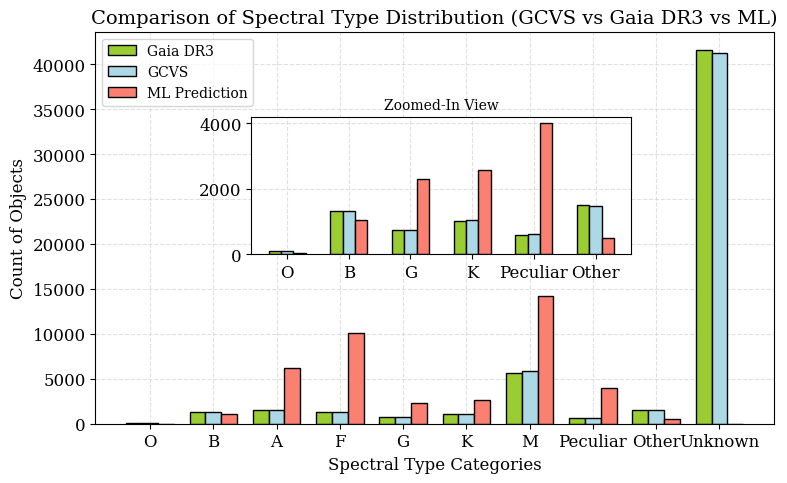

In [140]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Функция для категоризации спектральных типов
def categorize_spectral_type(spectral_type):
    if pd.isnull(spectral_type) or spectral_type.strip() == '':
        return "Unknown"
    elif spectral_type.startswith('O'):
        return "O"
    elif spectral_type.startswith('B'):
        return "B"
    elif spectral_type.startswith('A'):
        return "A"
    elif spectral_type.startswith('F'):
        return "F"
    elif spectral_type.startswith('G'):
        return "G"
    elif spectral_type.startswith('K'):
        return "K"
    elif spectral_type.startswith('M'):
        return "M"
    elif "pec" in spectral_type.lower():
        return "Peculiar"
    else:
        return "Other"

# Категоризация для каждого источника
spt_gaia = cat_final_cut["SpType"].apply(categorize_spectral_type)
spt_gcvs = cat_final_cut["SPECT_TYPE"].apply(categorize_spectral_type)
spt_ml = cat_final_cut["final_spect_type"][cat_final_cut["spt_source"] == 'ML Prediction'].apply(categorize_spectral_type)

# Уникальные категории для упорядочивания
desired_order = ["O", "B", "A", "F", "G", "K", "M", "Peculiar", "Other", "Unknown"]

# Подсчет объектов по категориям
category_counts_gaia = spt_gaia.value_counts().reindex(desired_order, fill_value=0)
category_counts_gcvs = spt_gcvs.value_counts().reindex(desired_order, fill_value=0)
category_counts_ml = spt_ml.value_counts().reindex(desired_order, fill_value=0)

# Формирование DataFrame для визуализации
category_data = pd.DataFrame({
    "Category": desired_order,
    "Gaia DR3": category_counts_gaia.values,
    "GCVS": category_counts_gcvs.values,
    "ML Prediction": category_counts_ml.values
})

# Визуализация распределения спектральных типов
fig, ax = plt.subplots(figsize=(8,5))

# Параметры для столбцов
bar_width = 0.25
x = range(len(desired_order))

# Построение столбцов
ax.bar([i - bar_width for i in x], category_data['Gaia DR3'], width=bar_width, label='Gaia DR3', color='yellowgreen', edgecolor='black')
ax.bar(x, category_data['GCVS'], width=bar_width, label='GCVS', color='lightblue', edgecolor='black')
ax.bar([i + bar_width for i in x], category_data['ML Prediction'], width=bar_width, label='ML Prediction', color='salmon', edgecolor='black')

# Настройка графика
ax.set_title('Comparison of Spectral Type Distribution (GCVS vs Gaia DR3 vs ML)', fontsize=14)
ax.set_xlabel('Spectral Type Categories', fontsize=12)
ax.set_ylabel('Count of Objects', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(desired_order, rotation=0)
ax.legend()
ax.grid(linestyle='--', alpha=0.7)

# Добавление встроенного графика для редких классов
inset_ax = inset_axes(ax, width="35%", height="35%", bbox_to_anchor=(-0.8, -0.2, 1.6, 1), bbox_transform=ax.transAxes)

# Выбираем категории для увеличенного графика
inset_categories = ["O", "B", "G","K","Peculiar", "Other"]
category_subset_gaia = category_counts_gaia.loc[inset_categories]
category_subset_gcvs = category_counts_gcvs.loc[inset_categories]
category_subset_ml = category_counts_ml.loc[inset_categories]

inset_x = range(len(inset_categories))
bar_width_inset = 0.2

# Построение встроенных столбцов
inset_ax.bar([i - bar_width_inset for i in inset_x], category_subset_gaia, width=bar_width_inset, label='Gaia DR3', color='yellowgreen', edgecolor='black')
inset_ax.bar(inset_x, category_subset_gcvs, width=bar_width_inset, label='GCVS', color='lightblue', edgecolor='black')
inset_ax.bar([i + bar_width_inset for i in inset_x], category_subset_ml, width=bar_width_inset, label='ML Prediction', color='salmon', edgecolor='black')

# Настройка встроенного графика
inset_ax.set_title('Zoomed-In View', fontsize=10)
inset_ax.set_xticks(inset_x)
inset_ax.set_ylim(0, 4200)
inset_ax.set_xticklabels(inset_categories, rotation=0)
inset_ax.grid(linestyle='--', alpha=0.7)

# Сохранение и вывод графика
plt.tight_layout()
plt.savefig('output/spectral_type_comparison.png', dpi=300)
plt.show()

/var/folders/kv/prhthx396zd4k1d7f55bdztc0000gn/T/ipykernel_20140/1963263792.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


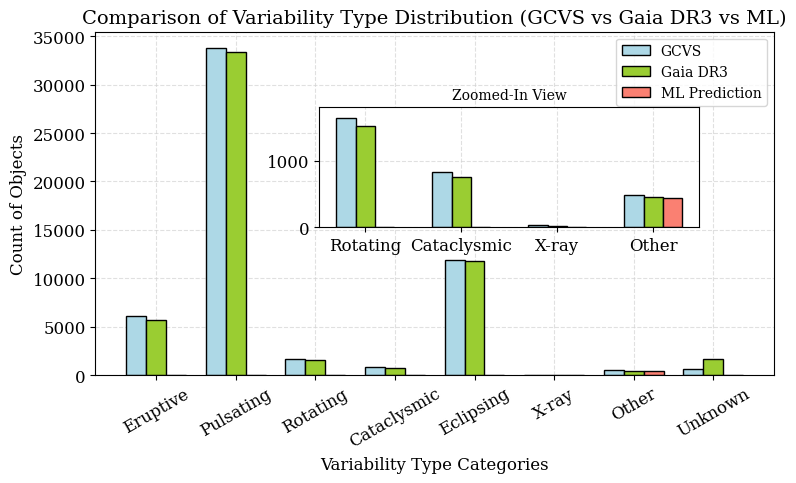

In [141]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# === Группировка типов переменности ===
variable_groups = {
    "Eruptive": ["FU", "GCAS", "I", "IA", "IB", "IN", "INA", "INB", "INT", "IT", "IN(YY)", "IS", "ISA", "ISA(YY)", 
                 "ISB", "INS", "INSA", "INSB", "INSB(YY)", "INST", "INST(YY)", "INAT", "UV", "UVN", "UVN(YY)", 
                 "WR", "RCB", "RS", "SDOR"],
    "Pulsating": ["ACYG", "BCEP", "BCEPS", "CEP", "CEP(B)", "CW", "CWA", "CWB", "DCEP", "DCEP(B)", "DCEPS", 
                  "DSCT", "DSCTC", "DSCTC(B)", "DSCT(B)", "GDOR", "L", "LB", "LC", "M", "PVTEL", "RPHS", "RR", 
                  "RRC", "RR(B)", "RRAB", "RRB", "RRA", "RVA", "RVB", "SR", "SRA", "SRB", "SRC", "SRD", "SXPHE", 
                  "SXPHE(B)", "ZZ", "ZZA", "ZZB", "LPB", "LPB(LBV)"],
    "Rotating": ["ACV", "ACVO", "BY", "ELL", "FKCOM", "PSR", "SXARI"],
    "Cataclysmic": ["N", "NA", "NB", "NC", "NL", "NR", "SN", "SNI", "SNII", "UG", "UGSS", "UGSU", "UGZ", "ZAND", "NAB"],
    "Eclipsing": ["E", "EA", "EB", "EW", "GS", "PN", "RS", "WD", "WR", "AR", "D", "DM", "DS", "DW", "K", "KE", "KW", "SD", "EC"],
    "X-ray": ["X", "XB", "XBND", "XNG", "XNGP", "XI", "XJ", "XND", "XN", "XN:", "XNG", "XPM", "XP", "XPNG", "XPR", 
              "XPRM", "XPM", "XBI", "XBPR", "XNDR", "XR:", "XM", "XF", "XR"],
    "Other": ["BLLAC", "CST", "GAL", "L:", "QSO", "S", "*", "+", ":", "VAR:"],
    "New": ["ZZO", "AM", "R", "BE", "BLBOO", "EP", "SRS", "LPB(LBV)"]
}

# === Функция для категоризации ===
def categorize_variability(var_type):
    if pd.isnull(var_type) or var_type.strip() == '':
        return "Unknown"
    for group, types in variable_groups.items():
        if any(vt in var_type for vt in types):
            return group
    return "Other"

# === Категоризация для каждого источника ===
var_gcvs = cat_final_cut["VARIABILITY_TYPE"].apply(categorize_variability)
var_gaia = cat_final_cut["VarType"].apply(categorize_variability)
var_ml = cat_final_cut["final_var_type"][cat_final_cut["var_source"] == 'ML Prediction'].apply(categorize_variability)

# === Уникальные категории для упорядочивания ===
desired_var_order = ["Eruptive", "Pulsating", "Rotating", "Cataclysmic", "Eclipsing", "X-ray", "Other", "Unknown"]

# === Подсчет объектов по категориям ===
category_counts_gcvs = var_gcvs.value_counts().reindex(desired_var_order, fill_value=0)
category_counts_gaia = var_gaia.value_counts().reindex(desired_var_order, fill_value=0)
category_counts_ml = var_ml.value_counts().reindex(desired_var_order, fill_value=0)

# === Формирование DataFrame для визуализации ===
category_data_var = pd.DataFrame({
    "Category": desired_var_order,
    "GCVS": category_counts_gcvs.values,
    "Gaia DR3": category_counts_gaia.values,
    "ML Prediction": category_counts_ml.values
})

# === Визуализация распределения типов переменности ===
fig, ax = plt.subplots(figsize=(8,5))

# Параметры для столбцов
bar_width = 0.25
x = range(len(desired_var_order))

# === Основной график ===
ax.bar([i - bar_width for i in x], category_data_var['GCVS'], width=bar_width, label='GCVS', color='lightblue', edgecolor='black')
ax.bar(x, category_data_var['Gaia DR3'], width=bar_width, label='Gaia DR3', color='yellowgreen', edgecolor='black')
ax.bar([i + bar_width for i in x], category_data_var['ML Prediction'], width=bar_width, label='ML Prediction', color='salmon', edgecolor='black')

# Настройка графика
ax.set_title('Comparison of Variability Type Distribution (GCVS vs Gaia DR3 vs ML)', fontsize=14)
ax.set_xlabel('Variability Type Categories', fontsize=12)
ax.set_ylabel('Count of Objects', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(desired_var_order, rotation=30)
ax.legend()
ax.grid(linestyle='--', alpha=0.7)

# === Добавление встроенного графика для "Rotating", "Cataclysmic", "X-ray" ===
inset_ax = inset_axes(ax, width="35%", height="35%", bbox_to_anchor=(-0.7, -0.2, 1.6, 1), bbox_transform=ax.transAxes)

# Выбираем категории для увеличенного графика
inset_categories = ["Rotating", "Cataclysmic", "X-ray", "Other"]
category_subset_gcvs = category_counts_gcvs.loc[inset_categories]
category_subset_gaia = category_counts_gaia.loc[inset_categories]
category_subset_ml = category_counts_ml.loc[inset_categories]

inset_x = range(len(inset_categories))
bar_width_inset = 0.2

# === Построение встроенного графика ===
inset_ax.bar([i - bar_width_inset for i in inset_x], category_subset_gcvs, width=bar_width_inset, label='GCVS', color='lightblue', edgecolor='black')
inset_ax.bar(inset_x, category_subset_gaia, width=bar_width_inset, label='Gaia DR3', color='yellowgreen', edgecolor='black')
inset_ax.bar([i + bar_width_inset for i in inset_x], category_subset_ml, width=bar_width_inset, label='ML Prediction', color='salmon', edgecolor='black')

# Настройка встроенного графика
inset_ax.set_title('Zoomed-In View', fontsize=10)
inset_ax.set_xticks(inset_x)
inset_ax.set_ylim(0, max(category_subset_gcvs.max(), category_subset_gaia.max(), category_subset_ml.max()) * 1.1)
inset_ax.set_xticklabels(inset_categories, rotation=0)
inset_ax.grid(linestyle='--', alpha=0.7)

# === Сохранение и вывод графика ===
plt.tight_layout()
plt.savefig('output/variability_type_comparison_with_inset.png', dpi=300)
plt.show()

In [147]:
cat_final_cut["final_spect_type_all"] = cat_final_cut["final_spect_type"].apply(categorize_spectral_type)
cat_final_cut["final_var_type_all"] = cat_final_cut["final_var_type"].apply(categorize_variability)



In [148]:
cat_final_cut.columns#["final_spect_type_all"].unique()

Index(['name_gcvs', 'ra_gcvs', 'dec_gcvs', 'SPECT_TYPE', 'min_mag_limit_gcvs',
       'min_mag_gcvs', 'max_mag_limit_gcvs', 'max_mag_gcvs',
       'VARIABILITY_TYPE', 'period_gcvs', 'var_star_num_gcvs',
       'var_star_cpt_gcvs', 'note_flag_gcvs', 'lii_gcvs', 'bii_gcvs',
       'pos_flag_gcvs', 'max_mag_flag_gcvs', 'min_mag_flag_gcvs',
       'min_mag_alt_sys_gcvs', 'sec_min_mag_limit_gcvs', 'sec_min_mag_gcvs',
       'sec_min_mag_flag_gcvs', 'sec_min_mag_alt_sys_gcvs', 'mag_sys_gcvs',
       'epoch_gcvs', 'epoch_prec_gcvs', 'epoch_flag_gcvs', 'nova_year_gcvs',
       'nova_year_flag_gcvs', 'period_prec_gcvs', 'period_note_gcvs',
       'rise_ecl_time_gcvs', 'rise_ecl_time_flag_gcvs', 'ecl_var_note_gcvs',
       'ref_star_gcvs', 'ref_chart_gcvs', 'comment_flag_gcvs', 'alt_name_gcvs',
       'coord_epoch_gcvs', 'coord_epoch_flag_gcvs', 'ref_astrometry_flag_gcvs',
       'ref_astrometry_gcvs', 'NEW_VARIABILITY_TYPE', 'class_gcvs',
       'source_id_gaia', 'parallax_gaia', 'pmra_gaia', '

In [149]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# === 🎨 Цвета для графика ===
color_list = ["lightblue", "yellowgreen",  "orange",  "steelblue", "salmon", "lightgreen"]

# === 🧮 Функция для поиска аутлаеров через IQR ===
def detect_outliers_iqr(data, column):
    """Находит аутлаеры через метод межквартильного размаха (IQR)."""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

# === 🧹 Создаем недостающие столбцы ===

# Амплитуда (разница между max и min магнитудой)
cat_final_cut['Amplitude'] = cat_final_cut['max_mag_gcvs'] - cat_final_cut['min_mag_gcvs']

# Галактическая высота (Z)
cat_final_cut['galactic_Z'] = cat_final_cut['d_tess'] * np.sin(np.radians(cat_final_cut['bii_gcvs']))

# === 📊 Параметры для анализа ===

# Спектральные параметры
spectral_params = ['period_gcvs', 'teff_gaia', 'mh_gaia', 'lum_tess', 'parallax_gaia', 'galactic_Z']

# Переменные параметры
variability_params = ['period_gcvs', 'Amplitude', 'rho_tess', 'mass_tess', 'teff_gaia']

Category: M, Total Count: 20179
Category: nan, Total Count: 0
Category: F, Total Count: 11403
Category: K, Total Count: 3705
Category: G, Total Count: 3077
Category: A, Total Count: 7775
Category: Peculiar, Total Count: 4643
Category: B, Total Count: 2403
Category: O, Total Count: 126


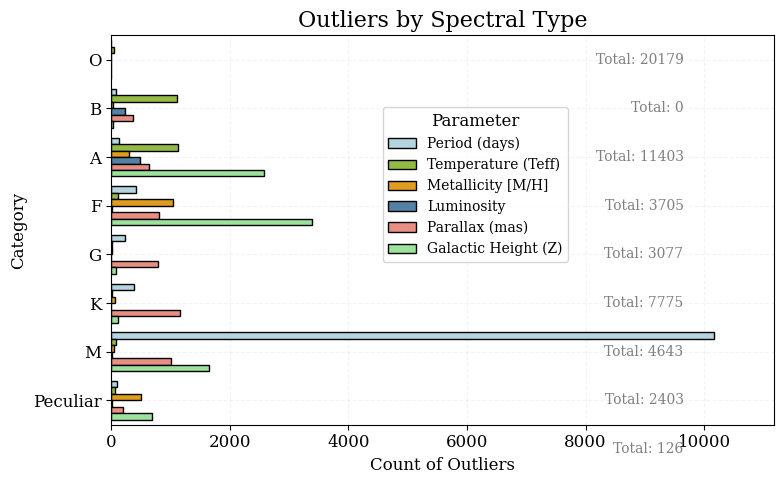

/var/folders/kv/prhthx396zd4k1d7f55bdztc0000gn/T/ipykernel_20140/4042862203.py:49: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  ax = sns.barplot(


Category: Pulsating, Total Count: 33798
Category: Eclipsing, Total Count: 11881
Category: Eruptive, Total Count: 6051
Category: Rotating, Total Count: 1639
Category: Cataclysmic, Total Count: 1005
Category: X-ray, Total Count: 31


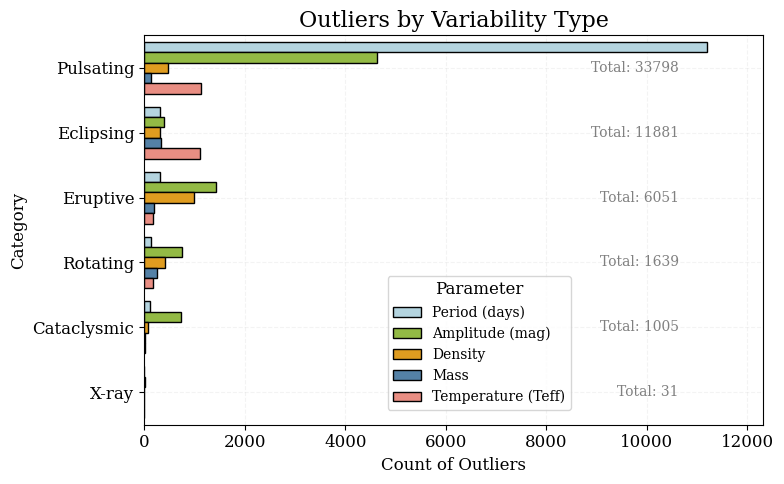

In [154]:
# === 📖 Словарь для читаемых названий параметров ===
param_labels = {
    'period_gcvs': 'Period (days)',
    'teff_gaia': 'Temperature (Teff)',
    'mh_gaia': 'Metallicity [M/H]',
    'lum_tess': 'Luminosity',
    'parallax_gaia': 'Parallax (mas)',
    'galactic_Z': 'Galactic Height (Z)',
    'Amplitude': 'Amplitude (mag)',
    'rho_tess': 'Density',
    'mass_tess': 'Mass',
}

# === 📊 Обновлённая функция для графика ===
def plot_outliers_by_category(df, category_col, params, title, category_order=None, exclude_unknown=False):
    outlier_data = []

    for param in params:
        # Преобразуем значения в числовой формат
        df[param] = pd.to_numeric(df[param], errors='coerce')

        # Находим аутлаеры
        outliers = detect_outliers_iqr(df, param)

        # Считаем аутлаеры по категориям
        counts = outliers[category_col].value_counts()
        total_counts = df[category_col].value_counts()

        for category in counts.index:
            if exclude_unknown and (category == "Unknown" or category == "New" or category ==  "Other"):
                continue
            outlier_data.append({
                'Category': category,
                'Parameter': param_labels.get(param, param),  # Используем читаемое название
                'Outlier_Count': counts[category],
                'Total_Objects': total_counts.get(category, 0)
            })

    # Переводим в DataFrame для графика
    df_outliers = pd.DataFrame(outlier_data)

    # 🟢 Упорядочиваем категории, если задано
    if category_order:
        cat_type = pd.api.types.CategoricalDtype(categories=category_order, ordered=True)
        df_outliers['Category'] = df_outliers['Category'].astype(cat_type)

    # === 📊 Построение графика ===
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        data=df_outliers,
        y='Category', x='Outlier_Count', hue='Parameter',
        palette=color_list, orient='h', edgecolor='black'
    )

    # Вычисляем максимальное значение для настройки лимита оси
    max_outlier = df_outliers['Outlier_Count'].max()
    plt.xlim(0, max_outlier * 1.1)

    # ✅ Добавляем общее количество объектов для каждой категории
    for i, category in enumerate(df_outliers['Category'].unique()):
        total = df[df[category_col] == category].shape[0]
        
        # 👀 Для отладки
        print(f"Category: {category}, Total Count: {total}")
    
        # Если категория пуста — выводим 0
        total_display = int(total) if total > 0 else 0
        ax.text(max_outlier * 0.95, i, f"Total: {total}", ha='right', va='center', fontsize=10, color='gray')

    # Оформление графика
    plt.title(title, fontsize=16)
    plt.xlabel("Count of Outliers", fontsize=12)
    plt.ylabel("Category", fontsize=12)
    plt.legend(title="Parameter", bbox_to_anchor=(0.7, 0.4))
    plt.grid()
    plt.tight_layout()
    plt.savefig("output/"+title+".png",dpi=300)
    plt.show()

# === ✅ Обновлённые списки параметров ===

# 🌟 Спектральные параметры
spectral_params = ['period_gcvs', 'teff_gaia', 'mh_gaia', 'lum_tess', 'parallax_gaia', 'galactic_Z']

# 🌟 Параметры переменности
variability_params = ['period_gcvs', 'Amplitude', 'rho_tess', 'mass_tess', 'teff_gaia']

# === 📊 Вызов для спектральных типов
plot_outliers_by_category(
    df=cat_final_cut,
    category_col='final_spect_type_all',
    params=spectral_params,
    title='Outliers by Spectral Type',
    category_order=["O", "B", "A", "F", "G", "K", "M", "Peculiar"]
)

# === 📊 Вызов для типов переменности
plot_outliers_by_category(
    df=cat_final_cut,
    category_col='final_var_type_all',
    params=variability_params,
    title='Outliers by Variability Type',
    category_order=["Pulsating", "Eclipsing", "Eruptive", "Rotating", "Cataclysmic", "X-ray"],
    exclude_unknown=True
)

/var/folders/kv/prhthx396zd4k1d7f55bdztc0000gn/T/ipykernel_20140/251000388.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


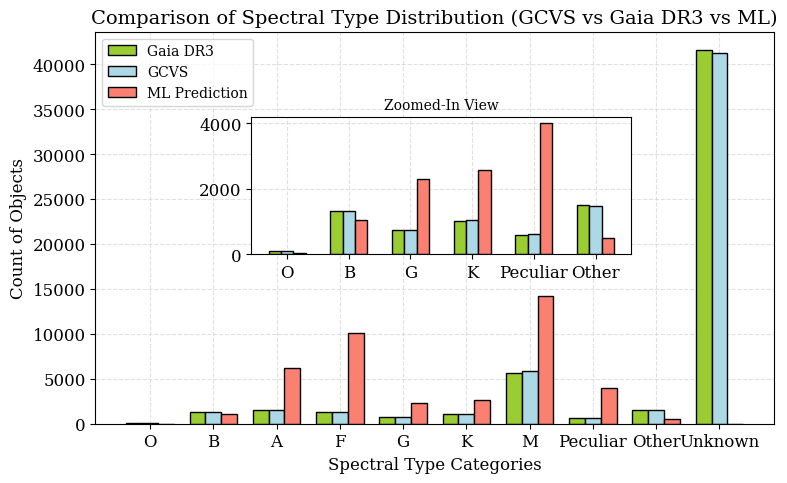

In [163]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Функция для категоризации спектральных типов
def categorize_spectral_type(spectral_type):
    if pd.isnull(spectral_type) or spectral_type.strip() == '':
        return "Unknown"
    elif spectral_type.startswith('O'):
        return "O"
    elif spectral_type.startswith('B'):
        return "B"
    elif spectral_type.startswith('A'):
        return "A"
    elif spectral_type.startswith('F'):
        return "F"
    elif spectral_type.startswith('G'):
        return "G"
    elif spectral_type.startswith('K'):
        return "K"
    elif spectral_type.startswith('M'):
        return "M"
    elif "pec" in spectral_type.lower():
        return "Peculiar"
    else:
        return "Other"

# Категоризация для каждого источника
spt_gaia = cat_final_cut["SpType"].apply(categorize_spectral_type)
spt_gcvs = cat_final_cut["SPECT_TYPE"].apply(categorize_spectral_type)
spt_ml = cat_final_cut["final_spect_type"][cat_final_cut["spt_source"] == 'ML Prediction'].apply(categorize_spectral_type)

# Уникальные категории для упорядочивания
desired_order = ["O", "B", "A", "F", "G", "K", "M", "Peculiar", "Other", "Unknown"]

# Подсчет объектов по категориям
category_counts_gaia = spt_gaia.value_counts().reindex(desired_order, fill_value=0)
category_counts_gcvs = spt_gcvs.value_counts().reindex(desired_order, fill_value=0)
category_counts_ml = spt_ml.value_counts().reindex(desired_order, fill_value=0)

# Формирование DataFrame для визуализации
category_data = pd.DataFrame({
    "Category": desired_order,
    "Gaia DR3": category_counts_gaia.values,
    "GCVS": category_counts_gcvs.values,
    "ML Prediction": category_counts_ml.values
})

# Визуализация распределения спектральных типов
fig, ax = plt.subplots(figsize=(8,5))

# Параметры для столбцов
bar_width = 0.25
x = range(len(desired_order))

# Построение столбцов
ax.bar([i - bar_width for i in x], category_data['Gaia DR3'], width=bar_width, label='Gaia DR3', color='yellowgreen', edgecolor='black')
ax.bar(x, category_data['GCVS'], width=bar_width, label='GCVS', color='lightblue', edgecolor='black')
ax.bar([i + bar_width for i in x], category_data['ML Prediction'], width=bar_width, label='ML Prediction', color='salmon', edgecolor='black')

# Настройка графика
ax.set_title('Comparison of Spectral Type Distribution (GCVS vs Gaia DR3 vs ML)', fontsize=14)
ax.set_xlabel('Spectral Type Categories', fontsize=12)
ax.set_ylabel('Count of Objects', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(desired_order, rotation=0)
ax.legend()
ax.grid(linestyle='--', alpha=0.7)

# Добавление встроенного графика для редких классов
inset_ax = inset_axes(ax, width="35%", height="35%", bbox_to_anchor=(-0.8, -0.2, 1.6, 1), bbox_transform=ax.transAxes)

# Выбираем категории для увеличенного графика
inset_categories = ["O", "B", "G","K","Peculiar", "Other"]
category_subset_gaia = category_counts_gaia.loc[inset_categories]
category_subset_gcvs = category_counts_gcvs.loc[inset_categories]
category_subset_ml = category_counts_ml.loc[inset_categories]

inset_x = range(len(inset_categories))
bar_width_inset = 0.2

# Построение встроенных столбцов
inset_ax.bar([i - bar_width_inset for i in inset_x], category_subset_gaia, width=bar_width_inset, label='Gaia DR3', color='yellowgreen', edgecolor='black')
inset_ax.bar(inset_x, category_subset_gcvs, width=bar_width_inset, label='GCVS', color='lightblue', edgecolor='black')
inset_ax.bar([i + bar_width_inset for i in inset_x], category_subset_ml, width=bar_width_inset, label='ML Prediction', color='salmon', edgecolor='black')

# Настройка встроенного графика
inset_ax.set_title('Zoomed-In View', fontsize=10)
inset_ax.set_xticks(inset_x)
inset_ax.set_ylim(0, 4200)
inset_ax.set_xticklabels(inset_categories, rotation=0)
inset_ax.grid(linestyle='--', alpha=0.7)

# Сохранение и вывод графика
plt.tight_layout()
plt.savefig('output/spectral_type_comparison.png', dpi=300)
plt.show()

/var/folders/kv/prhthx396zd4k1d7f55bdztc0000gn/T/ipykernel_20140/1963263792.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


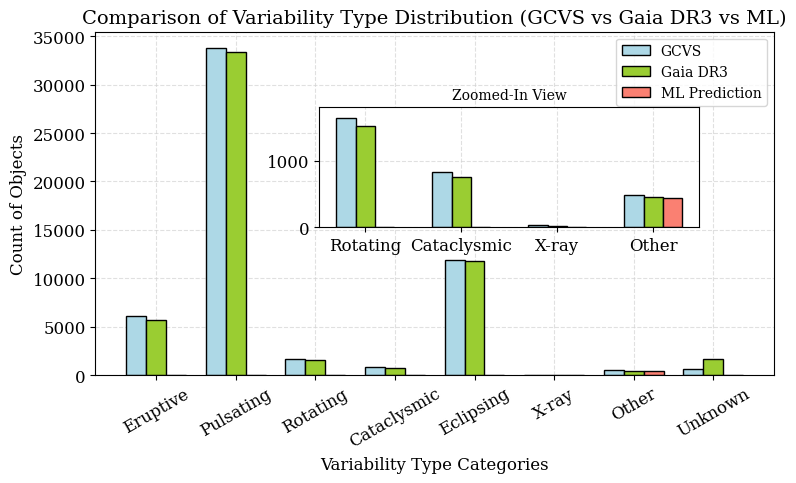

In [164]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# === Группировка типов переменности ===
variable_groups = {
    "Eruptive": ["FU", "GCAS", "I", "IA", "IB", "IN", "INA", "INB", "INT", "IT", "IN(YY)", "IS", "ISA", "ISA(YY)", 
                 "ISB", "INS", "INSA", "INSB", "INSB(YY)", "INST", "INST(YY)", "INAT", "UV", "UVN", "UVN(YY)", 
                 "WR", "RCB", "RS", "SDOR"],
    "Pulsating": ["ACYG", "BCEP", "BCEPS", "CEP", "CEP(B)", "CW", "CWA", "CWB", "DCEP", "DCEP(B)", "DCEPS", 
                  "DSCT", "DSCTC", "DSCTC(B)", "DSCT(B)", "GDOR", "L", "LB", "LC", "M", "PVTEL", "RPHS", "RR", 
                  "RRC", "RR(B)", "RRAB", "RRB", "RRA", "RVA", "RVB", "SR", "SRA", "SRB", "SRC", "SRD", "SXPHE", 
                  "SXPHE(B)", "ZZ", "ZZA", "ZZB", "LPB", "LPB(LBV)"],
    "Rotating": ["ACV", "ACVO", "BY", "ELL", "FKCOM", "PSR", "SXARI"],
    "Cataclysmic": ["N", "NA", "NB", "NC", "NL", "NR", "SN", "SNI", "SNII", "UG", "UGSS", "UGSU", "UGZ", "ZAND", "NAB"],
    "Eclipsing": ["E", "EA", "EB", "EW", "GS", "PN", "RS", "WD", "WR", "AR", "D", "DM", "DS", "DW", "K", "KE", "KW", "SD", "EC"],
    "X-ray": ["X", "XB", "XBND", "XNG", "XNGP", "XI", "XJ", "XND", "XN", "XN:", "XNG", "XPM", "XP", "XPNG", "XPR", 
              "XPRM", "XPM", "XBI", "XBPR", "XNDR", "XR:", "XM", "XF", "XR"],
    "Other": ["BLLAC", "CST", "GAL", "L:", "QSO", "S", "*", "+", ":", "VAR:"],
    "New": ["ZZO", "AM", "R", "BE", "BLBOO", "EP", "SRS", "LPB(LBV)"]
}

# === Функция для категоризации ===
def categorize_variability(var_type):
    if pd.isnull(var_type) or var_type.strip() == '':
        return "Unknown"
    for group, types in variable_groups.items():
        if any(vt in var_type for vt in types):
            return group
    return "Other"

# === Категоризация для каждого источника ===
var_gcvs = cat_final_cut["VARIABILITY_TYPE"].apply(categorize_variability)
var_gaia = cat_final_cut["VarType"].apply(categorize_variability)
var_ml = cat_final_cut["final_var_type"][cat_final_cut["var_source"] == 'ML Prediction'].apply(categorize_variability)

# === Уникальные категории для упорядочивания ===
desired_var_order = ["Eruptive", "Pulsating", "Rotating", "Cataclysmic", "Eclipsing", "X-ray", "Other", "Unknown"]

# === Подсчет объектов по категориям ===
category_counts_gcvs = var_gcvs.value_counts().reindex(desired_var_order, fill_value=0)
category_counts_gaia = var_gaia.value_counts().reindex(desired_var_order, fill_value=0)
category_counts_ml = var_ml.value_counts().reindex(desired_var_order, fill_value=0)

# === Формирование DataFrame для визуализации ===
category_data_var = pd.DataFrame({
    "Category": desired_var_order,
    "GCVS": category_counts_gcvs.values,
    "Gaia DR3": category_counts_gaia.values,
    "ML Prediction": category_counts_ml.values
})

# === Визуализация распределения типов переменности ===
fig, ax = plt.subplots(figsize=(8,5))

# Параметры для столбцов
bar_width = 0.25
x = range(len(desired_var_order))

# === Основной график ===
ax.bar([i - bar_width for i in x], category_data_var['GCVS'], width=bar_width, label='GCVS', color='lightblue', edgecolor='black')
ax.bar(x, category_data_var['Gaia DR3'], width=bar_width, label='Gaia DR3', color='yellowgreen', edgecolor='black')
ax.bar([i + bar_width for i in x], category_data_var['ML Prediction'], width=bar_width, label='ML Prediction', color='salmon', edgecolor='black')

# Настройка графика
ax.set_title('Comparison of Variability Type Distribution (GCVS vs Gaia DR3 vs ML)', fontsize=14)
ax.set_xlabel('Variability Type Categories', fontsize=12)
ax.set_ylabel('Count of Objects', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(desired_var_order, rotation=30)
ax.legend()
ax.grid(linestyle='--', alpha=0.7)

# === Добавление встроенного графика для "Rotating", "Cataclysmic", "X-ray" ===
inset_ax = inset_axes(ax, width="35%", height="35%", bbox_to_anchor=(-0.7, -0.2, 1.6, 1), bbox_transform=ax.transAxes)

# Выбираем категории для увеличенного графика
inset_categories = ["Rotating", "Cataclysmic", "X-ray", "Other"]
category_subset_gcvs = category_counts_gcvs.loc[inset_categories]
category_subset_gaia = category_counts_gaia.loc[inset_categories]
category_subset_ml = category_counts_ml.loc[inset_categories]

inset_x = range(len(inset_categories))
bar_width_inset = 0.2

# === Построение встроенного графика ===
inset_ax.bar([i - bar_width_inset for i in inset_x], category_subset_gcvs, width=bar_width_inset, label='GCVS', color='lightblue', edgecolor='black')
inset_ax.bar(inset_x, category_subset_gaia, width=bar_width_inset, label='Gaia DR3', color='yellowgreen', edgecolor='black')
inset_ax.bar([i + bar_width_inset for i in inset_x], category_subset_ml, width=bar_width_inset, label='ML Prediction', color='salmon', edgecolor='black')

# Настройка встроенного графика
inset_ax.set_title('Zoomed-In View', fontsize=10)
inset_ax.set_xticks(inset_x)
inset_ax.set_ylim(0, max(category_subset_gcvs.max(), category_subset_gaia.max(), category_subset_ml.max()) * 1.1)
inset_ax.set_xticklabels(inset_categories, rotation=0)
inset_ax.grid(linestyle='--', alpha=0.7)

# === Сохранение и вывод графика ===
plt.tight_layout()
plt.savefig('output/variability_type_comparison_with_inset.png', dpi=300)
plt.show()

Agreement Statistics:
spt_agreement
Agreed       54348
Disagreed     1028
Name: count, dtype: int64


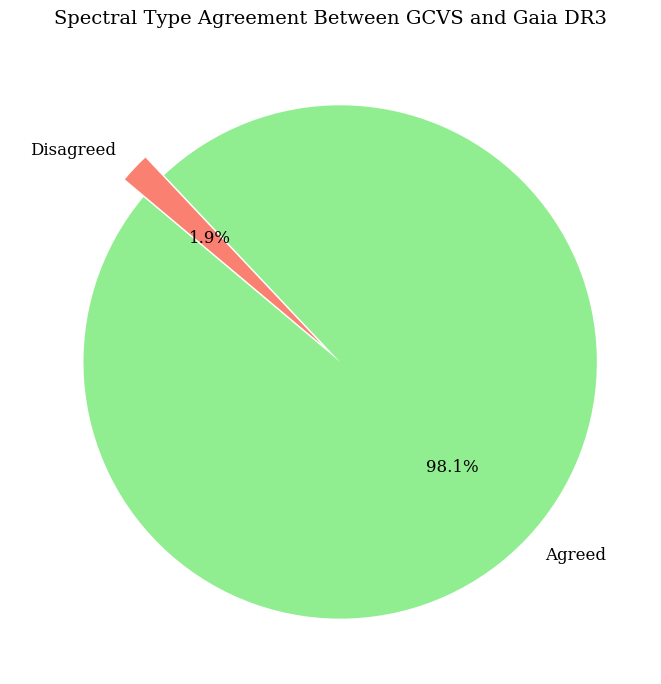

In [165]:

# Вытаскиваем данные для сравнения
gcvs_spt = spt_gcvs
gaia_spt = spt_gaia

# Функция для проверки согласованности
def check_agreement(gcvs, gaia):
    types = [gcvs, gaia]
    types = [t for t in types if pd.notna(t)]
    return "Agreed" if len(set(types)) == 1 else "Disagreed"

# Применяем функцию к каждой строке
cat_final_cut["spt_agreement"] = [check_agreement(g, ga) for g, ga in zip(gcvs_spt, gaia_spt)]

# Считаем статистику
agreement_stats = cat_final_cut["spt_agreement"].value_counts()

# Выводим результат
print("Agreement Statistics:")
print(agreement_stats)

# --------- 🎨 Pie Chart ---------
colors = ["lightgreen", "salmon"]  # Зеленый для "Agreed", красный для "Disagreed"
explode = (0.05, 0.05)           # Немного "вынесем" секторы для акцента

plt.figure(figsize=(7, 7))
plt.pie(
    agreement_stats, 
    labels=agreement_stats.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors, 
    explode=explode,
    textprops={'fontsize': 12}
)

plt.title("Spectral Type Agreement Between GCVS and Gaia DR3", fontsize=14)
plt.tight_layout()


# Сохранение и показ
plt.savefig("output/spt_agreement_piechart.png", dpi=300)
plt.show()

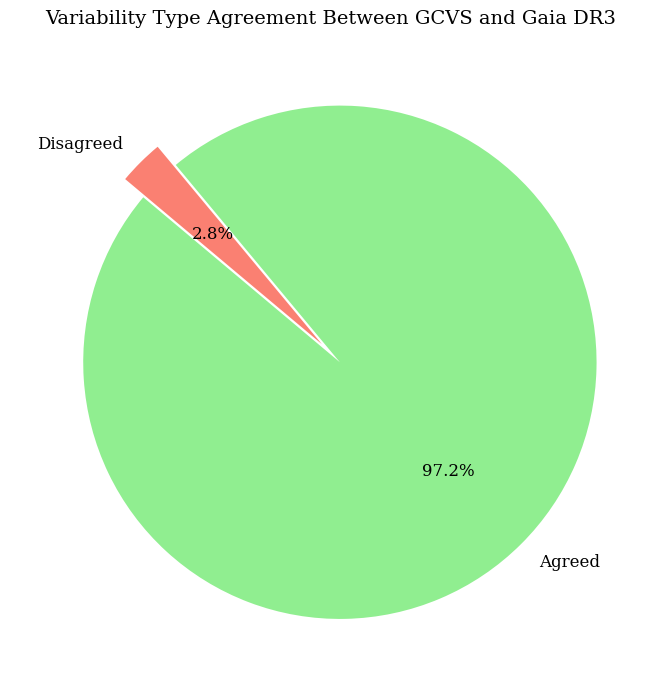

In [167]:
# === Функция для проверки согласованности ===
def check_var_agreement(gcvs, gaia):
    types = [gcvs, gaia]
    types = [t for t in types if pd.notna(t)]
    return "Agreed" if len(set(types)) == 1 else "Disagreed"

# === Применение функции ===
cat_final_cut["var_agreement"] = [check_var_agreement(g, ga) for g, ga in zip(var_gcvs, var_gaia)]

# === Подсчет статистики ===
agreement_stats_var = cat_final_cut["var_agreement"].value_counts()

# === Визуализация Pie Chart ===
colors = ["lightgreen", "salmon"]
explode = (0.05, 0.05)

plt.figure(figsize=(7, 7))
plt.pie(
    agreement_stats_var,
    labels=agreement_stats_var.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    textprops={'fontsize': 12}
)

plt.title("Variability Type Agreement Between GCVS and Gaia DR3", fontsize=14)
plt.tight_layout()
plt.savefig("output/var_agreement_piechart.png", dpi=300)
plt.show()

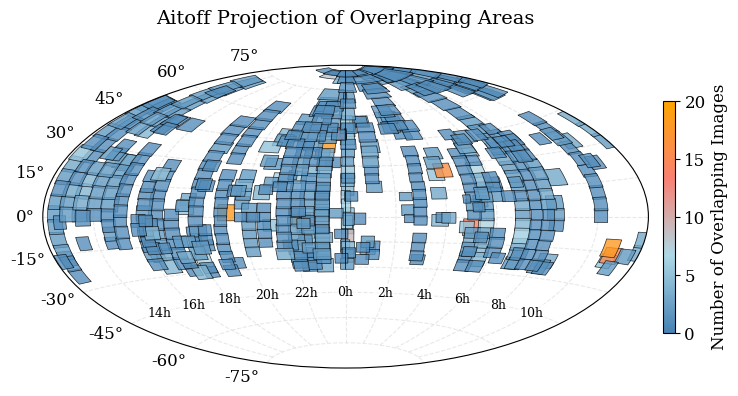

In [317]:
# === 📁 Чтение данных из файла ===
def parse_areas_from_file(filepath):
    areas = []
    with open(filepath, 'r') as file:
        area = {}
        for line in file:
            line = line.strip()
            if line.startswith("Area"):
                if area:
                    areas.append(area)
                area = {}
            elif line.startswith("RA:"):
                ra_range = line.split(":")[1].strip().split(" - ")
                area["RA_min"] = float(ra_range[0]) % 360
                area["RA_max"] = float(ra_range[1]) % 360
            elif line.startswith("Dec:"):
                dec_range = line.split(":")[1].strip().split(" - ")
                area["Dec_min"] = float(dec_range[0])
                area["Dec_max"] = float(dec_range[1])
            elif line.startswith("Number of Overlapping Images:"):
                area["Overlaps"] = int(line.split(":")[1].strip())
        if area:
            areas.append(area)
    return areas


# === 🛠️ Коррекция областей с RA > 180° и инверсией длинных интервалов ===
def fix_wrapping_areas(areas):
    fixed_areas = []
    for area in areas:
        ra_min, ra_max = area["RA_min"], area["RA_max"]

        # ✅ Если разрыв больше 180°, инвертируем
        if (ra_max - ra_min) % 360 > 180:
            ra_min, ra_max = ra_max, ra_min + 360  # Инверсия

        # 📏 Если всё равно пересекает 360°, разбиваем на две области
        if ra_max > 360:
            area1 = area.copy()
            area1["RA_min"] = ra_min % 360
            area1["RA_max"] = 360
            area2 = area.copy()
            area2["RA_min"] = 0
            area2["RA_max"] = ra_max % 360
            fixed_areas.extend([area1, area2])
        else:
            area["RA_min"] = ra_min % 360
            area["RA_max"] = ra_max % 360
            fixed_areas.append(area)

    return fixed_areas

# === 📊 Построение Aitoff-проекции ===
def plot_aitoff(areas):
    fig = plt.figure(figsize=(8,5))
    ax = fig.add_subplot(111, projection="aitoff")
    ax.grid(True, linestyle='--', alpha=0.5)

    # Нормализация для цветовой шкалы
    overlap_values = [area["Overlaps"] for area in areas]
    norm = Normalize(vmin=0, vmax=max(overlap_values))

    for area in areas:
        ra_center = ((area["RA_min"] + area["RA_max"]) / 2) % 360
        if ra_center > 180:
            ra_center -= 360
        ra_center_rad = np.radians(ra_center)

        dec_center = (area["Dec_min"] + area["Dec_max"]) / 2
        dec_center_rad = np.radians(dec_center)
        ra_width = np.radians(abs(area["RA_max"] - area["RA_min"]))
        dec_height = np.radians(abs(area["Dec_max"] - area["Dec_min"]))

        rect = patches.Rectangle(
            (ra_center_rad - ra_width/2, dec_center_rad - dec_height/2),
            ra_width, dec_height,
            linewidth=0.5, edgecolor='black',
            facecolor=custom_cmap(norm(area["Overlaps"])), alpha=0.8
        )
        ax.add_patch(rect)

    # ✅ Вертикальная цветовая шкала (уменьшена в 2 раза)
    sm = plt.cm.ScalarMappable(cmap=custom_cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02, shrink=0.5)
    cbar.set_label('Number of Overlapping Images', fontsize=12)

    # 📍 Подписи по RA на линии склонения -45°
    ra_labels = ['14h', '16h', '18h', '20h', '22h', '0h', '2h', '4h', '6h', '8h', '10h']
    ra_degrees = np.linspace(-150, 150, len(ra_labels))

    for ra_deg, label in zip(ra_degrees, ra_labels):
        ax.text(
            np.radians(ra_deg), np.radians(-45), label,
            ha='center', va='center', fontsize=9, color='black',
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.6)
        )

    # ❌ Убираем стандартные метки вдоль 0°
    ax.set_xticklabels([])

    # ⬆ Заголовок поднят выше
    plt.title('Aitoff Projection of Overlapping Areas', fontsize=14, pad=30)

    plt.tight_layout()
    plt.savefig("output/aitoff_proj.png",dpi=300)
    plt.show()

# === 🚀 Запуск ===
file_path = 'sky_areas_report.txt'  # 🟡 Укажи путь к файлу
areas_data = parse_areas_from_file(file_path)
fixed_areas = fix_wrapping_areas(areas_data)
plot_aitoff(fixed_areas)